# Technology comparison — traditional vs SMR, end to end

**What this notebook is.** The single end-to-end statement of the technology-choice case,
built to the ratified spec (`z-ethan/tech-comparison-notebook-spec.md`, decisions ratified
2026-08-06). It promotes to explicit axes the three things the existing four-notebook
evidence base holds fixed or leaves implicit: **(1) cross-tech dependence** (the coupling
κ between the two technologies' draws), **(2) the ex-ante commitment framing** (what a
planner who must commit *before* the uncertainty resolves should choose), and **(3) the
elicitation's shape/support choices** (optimism-bias, negative-learning, and peaked-shape
variants of the marginals). The headline deliverable is the **pre-registered claims ledger
C1–C7** (§T0) stamped with the region of assumption space where each claim holds — the
paper quotes regions, not points.

**Prerequisites.** Run `mc_cost_trajectories.ipynb` first (writes `exports/mc_perdraw.npz`
— the κ=1 cell *is* its draws, which is what makes the QA-C/QA-E pins exact), and
`npv_winner_check.ipynb` (writes `exports/npv_winner_summary.csv` / `npv_flips.csv` — the
validated capacity factor and the NPV flip register this notebook pins against).
`mixed_build_optimizer.ipynb`'s exports provide the κ=0 pin. Zero ReEDS runs.

**Naming note — three rhos, one κ.** The cross-tech coupling parameter here is **κ**
(`KAPPA_LR`, `KAPPA_BOAK`): the Gaussian-copula rank correlation between the two techs'
percentiles of the *same* quantity. It is distinct from `ces_rho` (the CES exponent over
experience channels — an engine parameter, untouched) and from `RHO_SETS` (the
*within-tech* lr↔boak latent correlation, held at the companion's moderate −0.3 —
untouched). κ=1 duplicates the latent — the exact comonotone `U0`/`U1` dial construction
of the companion MC (asserted as *equality*, not correlation ≈ 1); κ=0 is the
mixed-build independent draw.

**Discipline reminder** (the companion notebooks' rule, promoted to a house rule here):
every cost is **conditional on an imposed deployment schedule**, and every probability in
this notebook is **conditional on the stated dependence cell and marginal variant**. No
unconditional statement leaves this notebook.

In [1]:
# T0 — conventions, switches, claims-ledger scaffold. All analysis switches live here.
import json
import os
import time
import zlib
import hashlib
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats

# --- Paths: anchored to this notebook's folder, never the launch directory ---
NB_DIR = Path.cwd() if Path.cwd().name == "mc" else Path("z-ethan/mc").resolve()
assert (NB_DIR / "pris_loader.py").exists(), f"notebook folder not found from {Path.cwd()}"
REPO_ROOT = NB_DIR.parent.parent               # the ReEDS-nuclear-learning fork
MC_EXPORTS = NB_DIR / "exports"                # the companion notebooks' exports (pins)
EXPORTS = NB_DIR / "exports" / "tech_comparison"
PERDRAW_DIR = EXPORTS / "perdraw"              # per-draw npz, gitignored
FIGURES = NB_DIR / "figures"
for d in (EXPORTS, PERDRAW_DIR, FIGURES):
    d.mkdir(parents=True, exist_ok=True)

import sys
if str(NB_DIR) not in sys.path:                # make `import pris_loader` work from any launch dir
    sys.path.insert(0, str(NB_DIR))

NPZ_PATH = MC_EXPORTS / "mc_perdraw.npz"
assert NPZ_PATH.exists(), "exports/mc_perdraw.npz not found - run mc_cost_trajectories.ipynb first"

# --- Reproducibility: one master seed, independent named streams, every stream prefixed
# "tccomp/" so no stream can collide with any companion notebook's draws. Every stream
# name ever requested is recorded for the T10 seed-stream audit.
MASTER_SEED = 20260715
STREAMS_USED = []

def rng_stream(name):
    """An independent, reproducible random generator tied to a label (audited)."""
    assert name.startswith("tccomp/"), f"stream '{name}' missing the tccomp/ prefix"
    STREAMS_USED.append(name)
    return np.random.default_rng(np.random.SeedSequence((MASTER_SEED, zlib.crc32(name.encode()))))

# --- Analysis switches (rationale on every line; ratified 2026-08-06) ---
KAPPA_SWEEP = [1.0, 0.75, 0.5, 0.25, 0.0]  # the primary diagonal (kappa_lr = kappa_boak)
ANCHOR_KAPPAS = [1.0, 0.5, 0.0]            # anchor cells: variants run here only
SPLIT_PROBES = [(0.0, 1.0), (1.0, 0.0)]    # (kappa_lr, kappa_boak): "anchors ATB-coherent,
                                           # learning decoupled" + its mirror
RHO_WITHIN = -0.3                          # within-tech lr<->boak latent corr (companion
                                           # "moderate" set - untouched, see naming note)
N_DRAWS_TC = int(os.environ.get("TCCOMP_DRAWS", 10000))  # per (cell, schedule); any cell
                                           # run below 10k is RECORDED in metadata (no
                                           # silent caps - spec draw-count rule)
COST_OBJ_DEFAULT = "npv"                   # full program NPV (T3); capex = historical pin
ITC_GRID = [0.0, 0.3]                      # OBBBA parity, both techs; shown once (T3/T9)
FLEX_GRID = [0.0, 25.0, 50.0]              # $/kW-yr off SMR levelized FOM - a BOUND on the
                                           # dispatch asymmetry (mingen 0.4 vs 0.7), not a model
PHI_GRID = [0.0, 0.3, 0.5]                 # learning floor OCC_t >= phi*BOAK (T9); 0.5 = headline
OB_MULT = 1.5                              # optimism-bias: SMR-only anchor multiplier (T1)
NEGLR_LO = -0.15                           # negative-learning lower endpoint (France; US -30%
                                           # rejected - post-TMI shock)
C2_THRESH_PCT = 5.0                        # C2: P95 |margin| under large wins, % of program cost
C5_THRESH_PCT = 1.0                        # C5: adaptive option value, % of expected program cost
REP_SCHED = "McKinsey GEP 2025"            # representative schedule for worked examples

# --- The pre-registered claims, loaded as data (ratified 2026-08-06, before any grid run).
# Later cells stamp each claim with (supported, region, source cell, numbers).
CLAIMS = {
    "C1": dict(statement="SMR is the majority pure-program winner (P > 0.5) in every "
                         "schedule at every primary cell",
               falsified_by="any primary cell with P(SMR) < 0.5"),
    "C2": dict(statement="'when large wins, it wins narrowly': P95 of |margin| | large wins "
                         f"< {C2_THRESH_PCT}% of program cost at every primary cell",
               falsified_by="tail above threshold anywhere (expected to fail at low kappa - "
                            "pre-registered so the failure is a finding)"),
    "C3": dict(statement="Pure-SMR minimizes expected program NPV among all fixed strategies "
                         "in every schedule at every primary cell",
               falsified_by="any fixed strategy (incl. hedge mixes) beating it on E[cost]"),
    "C4": dict(statement="Pure-SMR second-order stochastically dominates pure-large at every "
                         "primary cell",
               falsified_by="an SSD crossing -> report location, downgrade to 'holds at CVaR95'"),
    "C5": dict(statement="Perfect-information option value of the 2036 switch is "
                         f"< {C5_THRESH_PCT}% of expected program cost in every schedule",
               falsified_by=">= 1% anywhere -> sequencing gets paper space"),
    "C6": dict(statement="C1 and C3 survive each single stress cell (OB x1.5, NEGLR sym, "
                         "NEGLR large_only, phi=0.5, FLEX_CREDIT, capex object, ITC) at the "
                         "three anchor kappa cells",
               falsified_by="a breaking cell -> named in the paper with its numbers"),
    "C7": dict(statement="No claim is made outside the ordered orthant (A2 off = modularity "
                         "premise fails); scope cells reported once as the boundary of validity",
               falsified_by="n/a (a scope statement; stamped with the scope-cell numbers)"),
}
for c in CLAIMS.values():
    c.update(supported=None, region="", source="", numbers="")

def stamp(cid, supported, region, source, numbers):
    CLAIMS[cid].update(supported=bool(supported), region=region, source=source, numbers=numbers)
    print(f"[ledger] {cid} {'SUPPORTED' if supported else 'NOT SUPPORTED'} - {numbers}")

# --- Shared figure tokens (the winner_boundary / npv_winner_check house system) ---
COL = {"large": "#2a78d6", "smr": "#eb6834"}
INK, MUTED, FAINT, GRID_C, EDGE_C, SURFACE = ("#0b0b0b", "#52514e", "#898781",
                                              "#e1e0d9", "#c3c2b7", "#fcfcfb")
mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": EDGE_C, "axes.labelcolor": MUTED, "text.color": INK,
    "xtick.color": FAINT, "ytick.color": FAINT, "axes.grid": True, "grid.color": GRID_C,
    "grid.linewidth": 0.8, "axes.axisbelow": True, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False, "axes.titlecolor": INK,
})
from matplotlib.colors import LinearSegmentedColormap
CMAP_PSMR = LinearSegmentedColormap.from_list(       # diverging: large-blue .. neutral .. smr-orange
    "psmr", [COL["large"], "#e8e7e2", COL["smr"]])

print(f"notebook dir : {NB_DIR}")
print(f"grid         : kappa sweep {KAPPA_SWEEP}, anchors {ANCHOR_KAPPAS}, "
      f"probes {SPLIT_PROBES}, N = {N_DRAWS_TC}/cell/schedule")
print(f"claims       : {len(CLAIMS)} pre-registered (C1-C7), thresholds "
      f"C2 < {C2_THRESH_PCT}%, C5 < {C5_THRESH_PCT}%")
print("discipline   : every probability below is conditional on (dependence cell, "
      "marginal variant, schedule); no unconditional statement leaves this notebook")

notebook dir : C:\Users\ethan\code\research\ReEDS-nuclear-learning\z-ethan\mc
grid         : kappa sweep [1.0, 0.75, 0.5, 0.25, 0.0], anchors [1.0, 0.5, 0.0], probes [(0.0, 1.0), (1.0, 0.0)], N = 10000/cell/schedule
claims       : 7 pre-registered (C1-C7), thresholds C2 < 5.0%, C5 < 1.0%
discipline   : every probability below is conditional on (dependence cell, marginal variant, schedule); no unconditional statement leaves this notebook


## Architecture and reuse

| Piece | Ported from | Guarantee |
|---|---|---|
| Learning engine (`experience_channels` / `occ_paths_ces`), durations, financing | `mixed_build_optimizer.ipynb` — itself a verbatim port of `mc_cost_trajectories.ipynb` S5–S7 | **QA-A** pins it bit-for-bit to a pasted copy of the companion engine at off settings; ccmult pin 1.268124 |
| Six deployment schedules | `inputs/nuclear_learning/US_SCHEDULES.csv` — the single source of truth; never redefined here | column/year-grid asserts on read |
| Non-CAPEX stack (avail-CF, ATB FOM/VOM, `om_at`/`om_npv`, `1/crf`) | `npv_winner_check.ipynb` N1/N2 | CF read from its validated export (the full ReEDS `avail` replication lives there); the `1/crf` identity re-asserted against the run's `crf.csv`; extended to **blended** programs, affinity asserted in **QA-G** |
| κ=1 draws | `exports/mc_perdraw.npz` — the companion MC's own worlds | dial identities + winner reproduction asserted (**QA-C/QA-E**) |
| κ<1 draws | this notebook, streams `tccomp/…` | ordered-rejection method of `mixed_build_optimizer`; **QA-F** marginal invariance |

In [2]:
# The six deployment schedules - read from the single source of truth, never redefined.
US_GW_2024 = 97.0
OFFSET_GW = 3.0

US_SCHEDULES_CSV = REPO_ROOT / "inputs" / "nuclear_learning" / "US_SCHEDULES.csv"
_sched_df = pd.read_csv(US_SCHEDULES_CSV, comment="#", index_col="year")

YEARS = np.arange(2024, 2051)
T = len(YEARS)
def yi(y):
    """Index of calendar year y in the YEARS grid."""
    return int(np.where(YEARS == y)[0][0])

ANCHOR = 2030
N_BOAK_UNITS = 2.0
OMEGA = 1.0 / 3.0
CES_RHO_GRID = np.array([-1.0, 0.0, 1.0])
X_SPILL_MAX = 0.30       # cross-tech spillover draw bound (kept: 2026-08-06 routing decision)
TECH = {
    "large": {"unit_gw": 1.000, "lr_lo": 0.03, "lr_hi": 0.12,
              "boak_lo": 5250.0, "boak_hi": 7750.0},
    "smr":   {"unit_gw": 0.300, "lr_lo": 0.03, "lr_hi": 0.16,
              "boak_lo": 5500.0, "boak_hi": 10000.0},
}
UNIT_FOREIGN_GW = 1.0
U_GRID = np.linspace(0.0, 1.0, 21)

TOKEN_NAME = {"eia_aeo_high": "EIA 2026 AEO high", "abou_jaoude": "Abou-Jaoude mod",
              "iaea_high": "IAEA high", "mckinsey": "McKinsey GEP 2025",
              "cop28": "COP28 tripling pledge", "eo2025": "2025 EO"}
assert set(_sched_df.columns) == set(TOKEN_NAME), "US_SCHEDULES.csv columns changed"
assert list(_sched_df.index) == list(YEARS), "US_SCHEDULES.csv year grid changed"

US_SCHEDULES = {TOKEN_NAME[tok]: _sched_df[tok].to_numpy(float) for tok in TOKEN_NAME}
SCHED_ORDER = list(US_SCHEDULES)
SCEN_TOKEN = {v: k for k, v in TOKEN_NAME.items()}

BUILD_YEARS = np.arange(2031, 2051)
N_P = len(BUILD_YEARS)
BUILD_SLICE = slice(yi(2031), yi(2050) + 1)

print("schedules loaded (2050 capacity in working GW basis):")
for name in SCHED_ORDER:
    print(f"  {name:22s} {US_SCHEDULES[name][-1] - OFFSET_GW:5.0f} GW")

schedules loaded (2050 capacity in working GW basis):
  EIA 2026 AEO high        114 GW
  Abou-Jaoude mod          131 GW
  IAEA high                169 GW
  McKinsey GEP 2025        197 GW
  COP28 tripling pledge    297 GW
  2025 EO                  397 GW


In [3]:
# Historical and international experience - ported verbatim from the companion S3 via
# mixed_build_optimizer (regional milestones, PRIS load, retirement identity, committed
# pipeline, historical stocks). See mc_cost_trajectories S3 for the full walkthrough.
REGION_MILESTONES = {
    "CA":  (12.7, 12.7, 12.7, 18.8, 23.0, 30.0, 63.7),
    "SAM": (5.1, 5, 5, 8, 11, 8, 20),
    "WEU": (95.4, 86, 92, 81, 114, 68, 136),
    "EEU": (53.6, 57, 57, 58, 82, 68, 103),
    "AF":  (1.9, 4, 5, 7, 12, 12, 30),
    "WA":  (5.8, 11, 11, 12, 20, 15, 35),
    "SA":  (11.1, 18, 22, 25, 43, 45, 85),
    "CEA": (94.5, 136, 144, 215, 264, 242, 328),
    "SEA": (0, 0, 0, 3, 7, 4, 18),
    "OC":  (0, 0, 0, 0, 0, 0, 2),
}
THETA_KV = {"CA": 0.28, "SAM": 0.14, "WEU": 0.17794117647, "EEU": 0.1325, "AF": 0.16688725490,
            "WA": 0.13375, "SA": 0.185, "CEA": 0.135, "SEA": 0.16583333, "OC": 0.18}
REGIONS = list(THETA_KV.keys())

import pris_loader as pl

PRIS_UNITS = pl.load_units(str(NB_DIR / "rds2_2025_units.csv"))
_milestones_2024 = {r: REGION_MILESTONES[r][0] for r in REGIONS} | {"US": US_GW_2024}
_issues = pl.validate_units(PRIS_UNITS[PRIS_UNITS["status"] == "operational"], _milestones_2024)
assert not _issues, _issues

FLEET = PRIS_UNITS[PRIS_UNITS["status"] == "operational"]
UC_UNITS = PRIS_UNITS[PRIS_UNITS["status"] == "under construction"]

def retirement_flow_gw(key, life_yr):
    """GW retiring per model year, from each unit's real grid-connection date + a lifetime rule."""
    return pl.retirement_schedule(FLEET, pd.Index(YEARS), lifetime_years=life_yr,
                                  region=key).to_numpy()

PIPE_END = 2030   # pipeline's real visibility horizon; structurally zero after 2030 (mc S3)
PIPELINE_GW = {r: pl.committed_pipeline(UC_UNITS[UC_UNITS["region"] == r],
                                        pd.Index(np.arange(2025, PIPE_END + 1)),
                                        lead_time_months=72).to_dict()
               for r in REGIONS}

_ever = PRIS_UNITS[(PRIS_UNITS["status"] != "under construction")
                   & PRIS_UNITS["grid_connection"].notna()]
HIST_UNITS = {r: int((_ever["region"] == r).sum()) for r in REGIONS + ["US"]}

US_LICENSE_LIFE = 80.0
ONE_FACTOR_DELTA = 0.0

print(f"PRIS fleet loaded: {len(FLEET)} operational, {len(UC_UNITS)} under construction")

PRIS fleet loaded: 417 operational, 62 under construction

In [4]:
# Foreign stocks on the u grid + per-schedule gross GW additions (ported verbatim).
def net_path_gw(region, u):
    """Regional net capacity path: interpolate the 2024/2030/2040/2050 milestones, positioned
    between Low and High by the global deployment draw u."""
    c = REGION_MILESTONES[region]
    vals = [c[0], c[1] + u*(c[2]-c[1]), c[3] + u*(c[4]-c[3]), c[5] + u*(c[6]-c[5])]
    return np.interp(YEARS, [2024, 2030, 2040, 2050], vals)

def gross_additions_gw(region, u):
    """The retirement identity: builds = max(0, capacity change + retirements); the committed
    pipeline REPLACES the interpolated path through PIPE_END = 2030."""
    dnet = np.diff(net_path_gw(region, u), prepend=net_path_gw(region, u)[0])
    ret = retirement_flow_gw(region, 65.0 + 5.0*u)   # IAEA-calibrated lives, 65+5u
    g = np.clip(dnet + ret, 0.0, None)
    pipe_mask = YEARS <= PIPE_END
    g[pipe_mask] = [PIPELINE_GW[region].get(int(y), 0.0) for y in YEARS[pipe_mask]]
    return g

REGION_STOCK = {}
for r in REGIONS:
    m_a = np.empty((len(U_GRID), T))
    for gi, u in enumerate(U_GRID):
        flow = gross_additions_gw(r, u)
        flow = flow.copy(); flow[YEARS <= ANCHOR] = 0.0
        m_a[gi] = np.cumsum(flow) / UNIT_FOREIGN_GW
    REGION_STOCK[r] = m_a

US_RET = retirement_flow_gw("US", US_LICENSE_LIFE)
GW_ADD = {}
for name in SCHED_ORDER:
    cap = US_SCHEDULES[name] - OFFSET_GW
    dnet = np.diff(cap, prepend=cap[0])
    flow = np.clip(dnet + US_RET, 0.0, None)
    flow[YEARS <= ANCHOR] = 0.0
    GW_ADD[name] = flow

print("total post-2030 gross additions per schedule (GW):")
for name in SCHED_ORDER:
    print(f"  {name:22s} {GW_ADD[name].sum():6.1f} GW over {int((GW_ADD[name] > 0).sum())} build years")

total post-2030 gross additions per schedule (GW):
  EIA 2026 AEO high        20.7 GW over 15 build years
  Abou-Jaoude mod          36.4 GW over 20 build years
  IAEA high                75.7 GW over 20 build years
  McKinsey GEP 2025       103.4 GW over 20 build years
  COP28 tripling pledge   203.4 GW over 20 build years
  2025 EO                 303.4 GW over 20 build years


In [5]:
# The learning-curve engine - verbatim port (mixed_build_optimizer / mc S5). Cross-tech
# spillover via n_oth/x_in; S_KV caching for hot loops. QA-A pins this bit-for-bit.
H_ALL_W = sum(THETA_KV[r]*HIST_UNITS[r] for r in REGIONS)   # theta-weighted historical foreign stock

def lag1(a):
    """One-year completion lag along the time axis: the stock ENTERING year t is the builds
    completed through t-1 (applied at the pricing boundary; companion-identical)."""
    a = np.asarray(a, float)
    out = np.zeros_like(a)
    out[..., 1:] = a[..., :-1]
    return out

OTHER_TECH = {"large": "smr", "smr": "large"}
X_IN_COL = {"large": "x_sl", "smr": "x_ls"}     # incoming cross-tech fraction, per receiving tech

def intl_stock(world):
    """Theta-weighted foreign post-anchor stock, (n_draws, T), UNLAGGED - depends only on the
    drawn u, so callers evaluating many share profiles compute it once and pass it back in."""
    n = len(world)
    u_r = np.repeat(world["u"].values[:, None], len(REGIONS), axis=1)
    gi = np.clip(np.rint(u_r * (len(U_GRID)-1)).astype(int), 0, len(U_GRID)-1)
    S = np.zeros((n, T))
    for j, r in enumerate(REGIONS):
        S += THETA_KV[r] * REGION_STOCK[r][gi[:, j], :]
    return S

def experience_channels(world, tech, n_us, n_oth=None, x_in=None, S_KV=None):
    """The two experience stocks O_d(t) (own) and A_d(t) (cross-firm), each (n_draws, T).
    Companion-identical math (mc S5); x_in/S_KV are hot-loop conveniences asserted neutral
    in QA-A. n_oth is the OTHER technology's cumulative post-anchor US units."""
    n = len(world)
    if S_KV is None:
        S_KV = intl_stock(world)
    skv = lag1(S_KV)
    N_us = lag1(np.broadcast_to(np.asarray(n_us, float), (n, T)))
    conv = world["conv_full"].values[:, None].astype(float)
    m = world["n_vendors"].values[:, None].astype(float)
    s = world["s"].values[:, None]
    # US historical fleet counts toward LARGE only (companion D8'): the SMR learning-rate
    # range already embeds any benefit from the prior LWR builds.
    hist_us = HIST_UNITS["US"] if tech == "large" else 0.0
    own0 = N_BOAK_UNITS + conv*hist_us/m
    own = own0 + N_us/m
    oth = (m-1.0)*own0 + N_us*(m-1.0)/m \
          + s*(conv*H_ALL_W + skv)
    if n_oth is not None:
        x = np.asarray(world[X_IN_COL[tech]].values if x_in is None else x_in, float)
        if x.ndim == 1:
            x = x[:, None]
        N_oth = lag1(np.broadcast_to(np.asarray(n_oth, float), (n, T)))
        oth = oth + x * N_oth
    return own, oth

CES_EPS = 1e-8

def occ_paths_ces(world, tech, n_us, n_oth=None, x_in=None, ces_rho=None, S_KV=None):
    """Production OCC engine (companion D11/D12, ported verbatim). $/kW (2022 USD), (n_draws, T).
    Note the engine is well-defined for NEGATIVE learning rates (b flips sign, costs rise
    with experience) - the NEGLR marginal variant relies on this; lr = 0 exactly would be
    a 0/0 in the weight w, which the draw cell excludes (measure zero, nudged)."""
    own, oth = experience_channels(world, tech, n_us, n_oth=n_oth, x_in=x_in, S_KV=S_KV)
    assert own.min() >= N_BOAK_UNITS and oth.min() >= N_BOAK_UNITS, "stock below anchor base; log unsafe"
    lr = world[f"lr_{tech}"].values[:, None]
    b1, b2 = np.log2(1.0 - lr), np.log2(1.0 - OMEGA*lr)
    b, w = -(b1 + b2), b1/(b1 + b2)
    rho = world["ces_rho"].values if ces_rho is None else np.full(len(world), float(ces_rho))
    rho = rho[:, None]
    geo = np.abs(rho) < CES_EPS
    lnO, lnA = np.log(own), np.log(oth)
    with np.errstate(over="raise"):
        lnE = np.where(geo, w*lnO + (1.0-w)*lnA,
                       lnO + np.log1p((1.0-w)*np.expm1(np.where(geo, 0.0, rho)*(lnA - lnO)))
                           / np.where(geo, 1.0, rho))
    return world[f"boak_{tech}"].values[:, None] * np.exp(-b*(lnE - lnE[:, [yi(ANCHOR)]]))

def percentile_table(paths, ps=(5, 25, 50, 75, 95)):
    """Yearly percentiles of a (n_draws, T) trajectory array."""
    return pd.DataFrame({f"P{p}": np.percentile(paths, p, axis=0) for p in ps}, index=YEARS)

print(f"engine loaded: theta-weighted historical foreign stock H = {H_ALL_W:.1f} units")

engine loaded: theta-weighted historical foreign stock H = 83.5 units


In [6]:
# Construction durations and financing - verbatim ports (companion S6-S7 via mixed_build).
DUR_UNITS = pl.duration_panel(PRIS_UNITS)
DUR_UNITS = DUR_UNITS[DUR_UNITS["family"].isin(["AP1000", "APR1400", "HPR1000"])].reset_index(drop=True)
DUR_UNITS = DUR_UNITS.rename(columns={"reactor_name": "unit"})

def fit_family_fe(df):
    """ln(duration) = family intercepts + b*ln(family sequence); returns (coefficients, residual sd)."""
    X = np.column_stack([np.ones(len(df)),
                         (df["family"] == "APR1400").astype(float),
                         (df["family"] == "HPR1000").astype(float),
                         np.log(df["family_seq"].astype(float))])
    Y = np.log(df["months"].values)
    beta, *_ = np.linalg.lstsq(X, Y, rcond=None)
    resid = Y - X @ beta
    return beta, resid.std(ddof=min(4, len(df)-1))

beta_hat, sig_hat = fit_family_fe(DUR_UNITS)

INL_DUR_MOD = np.array([118.0, 88.0, 74.0, 67.0, 62.0, 59.0, 56.0, 54.0, 52.0, 50.0])
INL_DUR_OPT = np.array([118.0, 70.0, 57.0, 49.0, 45.0, 42.0, 40.0, 38.0, 37.0, 36.0])
SMR_DUR_RATIO = 55.0/82.0
SMR_DUR_FLOOR = 43.0

def duration_paths(world, tech, n_us):
    """Construction duration (months) per draw-year from the INL series curves; the series
    clock runs on a vendor's OWN projects only (spillover never shortens schedules)."""
    n = len(world)
    N_us = lag1(np.broadcast_to(np.asarray(n_us, float), (n, T)))
    n_own = N_us / world["n_vendors"].values[:, None]
    series = np.clip(2 + np.floor(n_own/2.0).astype(int), 2, len(INL_DUR_MOD))
    opt, mod = np.take(INL_DUR_OPT, series-1), np.take(INL_DUR_MOD, series-1)
    base = opt + world["dur_lambda"].values[:, None]*(mod - opt)
    if tech == "smr":
        base = np.maximum(base * SMR_DUR_RATIO, SMR_DUR_FLOOR)
    return base * np.exp(world["dur_z"].values[:, None]*sig_hat)

FIN_DIR = REPO_ROOT / "inputs" / "financials"

def load_reeds_financials():
    """ReEDS financial inputs on the YEARS grid, exactly as reeds/financials.py derives them."""
    sys_fin = pd.read_csv(FIN_DIR / "financials_sys_ATB2024.csv")
    infl = pd.read_csv(FIN_DIR / "inflation_default.csv")
    sys_fin = sys_fin.merge(infl, on="t", how="left")
    sys_fin["d_nom"] = ((1 - sys_fin["debt_fraction"]) * (sys_fin["rroe_nom"] - 1)
                        + sys_fin["debt_fraction"] * (sys_fin["interest_rate_nom"] - 1)
                          * (1 - sys_fin["tax_rate"]) + 1)
    sys_fin["d_real"] = sys_fin["d_nom"] / sys_fin["inflation_rate"]
    tech_fin = pd.read_csv(FIN_DIR / "financials_tech_ATB2024.csv")
    tech_fin = tech_fin[tech_fin["i"].isin(["Nuclear", "Nuclear-SMR"])]
    dep = pd.read_csv(FIN_DIR / "depreciation_schedules_default.csv")
    cs = pd.read_csv(FIN_DIR / "construction_schedules_default.csv")

    def on_years(col):
        s = sys_fin.set_index("t")[col].reindex(range(1990, YEARS[-1] + 1)).ffill()
        return s.loc[YEARS].to_numpy(float)

    out = {"interest_base": on_years("interest_rate_nom"), "tax_rate": on_years("tax_rate"),
           "d_nom": on_years("d_nom"), "d_real": on_years("d_real"),
           "pv_dep": {}, "risk_mult": {}, "eval_adj": {}, "sched": {}}
    SYS_EVAL_YEARS = 30
    sys_pvf_sum = (1 - (1/out["d_real"])**(SYS_EVAL_YEARS - 1)) / (out["d_real"] - 1.0) + 1
    REEDS_TECH_NAME = {"large": "Nuclear", "smr": "Nuclear-SMR"}
    for tech, iname in REEDS_TECH_NAME.items():
        row = tech_fin[tech_fin["i"] == iname].iloc[-1]
        dep_frac = dep[str(int(row["depreciation_sch"]))].to_numpy(float)
        out["pv_dep"][tech] = np.array([np.sum(dep_frac / dn**np.arange(1, 22))
                                        for dn in out["d_nom"]])
        eval_p = float(row["eval_period"])
        out["risk_mult"][tech] = 1.0 + float(row["finance_diff_real"]) * (
            (1 - (1/out["d_real"])**eval_p) / (out["d_real"] - 1.0))
        tech_pvf_sum = (1 - (1/out["d_real"])**(eval_p - 1)) / (out["d_real"] - 1.0) + 1
        out["eval_adj"][tech] = sys_pvf_sum / tech_pvf_sum
        frac = pd.to_numeric(cs[str(row["construction_sch"])], errors="coerce").fillna(0.0).to_numpy()
        nz = np.flatnonzero(frac > 0)
        assert nz.size and nz[-1] - nz[0] + 1 == nz.size, \
            f"{iname}: spend profile has interior zeros"
        out["sched"][tech] = frac[nz[0]:nz[-1] + 1]
    return out

FIN = load_reeds_financials()

def _resample_schedule(frac, n_years):
    """Stretch/compress a spend-fraction profile to n_years bins (sum to 1)."""
    frac = np.asarray(frac, float)
    n0 = len(frac)
    if n_years == n0:
        return frac / frac.sum()
    cdf = np.concatenate([[0.0], np.cumsum(frac)])
    xq = np.linspace(0.0, 1.0, n_years + 1)
    cdf_q = np.interp(xq, np.linspace(0.0, 1.0, n0 + 1), cdf)
    new = np.diff(cdf_q)
    return new / new.sum()

def ccmult_from_duration(duration_mo, interest_base, canonical_frac):
    """Construction-financing (IDC) multiplier for a learned duration (verbatim ReEDS port)."""
    n_years = int(round(duration_mo / 12.0))
    n_years = max(1, min(n_years, 10))
    x = _resample_schedule(canonical_frac, n_years)
    exps = np.arange(n_years) + 0.5
    return 1.0 + float(np.sum(x * (interest_base ** exps - 1.0)))

def _ccm_table(tech):
    ib = FIN["interest_base"]
    table = np.empty((10 + 1, T))
    for nyr in range(1, 11):
        x = _resample_schedule(FIN["sched"][tech], nyr)
        exps = np.arange(nyr) + 0.5
        table[nyr] = 1.0 + (x[:, None] * (ib[None, :] ** exps[:, None] - 1.0)).sum(axis=0)
    return table

CCM_TABLE = {tech: _ccm_table(tech) for tech in TECH}

def ccmult_grid(dur_months, tech):
    """Vectorized ccmult for a (n_draws, T) duration array."""
    n_years = np.clip(np.round(np.asarray(dur_months)/12.0).astype(int), 1, 10)
    return CCM_TABLE[tech][n_years, np.arange(T)[None, :]]

def fin_mult_rest(tech):
    """Everything in ReEDS's cost_cap_fin_mult EXCEPT ccmult, per year (T,) - verbatim port.
    The T3 ITC variant is applied downstream as a stylized (1 - ITC) scalar on financed
    CAPEX for BOTH techs (OBBBA parity), not here."""
    tax, pv_dep = FIN["tax_rate"], FIN["pv_dep"][tech]
    return (1.0/(1.0 - tax)) * (1.0 - tax*pv_dep) * FIN["risk_mult"][tech] * FIN["eval_adj"][tech]

FIN_REST = {tech: fin_mult_rest(tech) for tech in TECH}
DISC = np.cumprod(np.where(YEARS > ANCHOR, FIN["d_real"], 1.0))   # discount to 2030

print(f"duration panel: {len(DUR_UNITS)} units, residual sd = {sig_hat:.3f} log-months")
print("financing loaded; full multiplier at 2035, at each tech's default duration:")
for tech, default_mo in [("large", 72.0), ("smr", 36.0)]:
    ccm = ccmult_from_duration(default_mo, FIN["interest_base"][yi(2035)], FIN["sched"][tech])
    print(f"  {tech}: ccmult = {ccm:.4f}, fin_mult_noITC = {ccm*FIN_REST[tech][yi(2035)]:.4f}")

duration panel: 21 units, residual sd = 0.116 log-months
financing loaded; full multiplier at 2035, at each tech's default duration:
  large: ccmult = 1.2681, fin_mult_noITC = 1.5145
  smr: ccmult = 1.0898, fin_mult_noITC = 1.3015


## T1 — Marginals with provenance

One row per drawn parameter: support, shape, source, and (backfilled by T8) which claims
are decision-sensitive to it.

**Source note (carried into methods).** Both anchor ranges come from **INL/RPT-24-77048
Rev 2** (Abou-Jaoude et al. 2024) with symmetric GN-COA processing, but **asymmetric
evidence classes**: the large-reactor range is partially anchored on *realized* builds
(EEDB, PWR/BWR history, AP1000 — "for larger reactors, actual learning rates from
deployments were used"), while the SMR range rests on *vendor bottom-up estimates with
zero completed units* ("No SMRs were previously built"). That asymmetry is the OB
variant's justification.

Marginal variants are **explicit transforms of the same latent uniforms** (variants
comparable draw-for-draw within a cell); orderings are re-enforced by rejection on the
*transformed* values, so each variant cell stays inside the ordered orthant it claims:

- **`OB ∈ {off, on}` — SMR-only ×1.5 anchor multiplier** (effective range
  \$8,250–15,000/kW). Basis: the estimate-class asymmetry above + Merrow (RAND, pioneer
  plants ≈×2 nominal FOAK growth) + NuScale CFPP 2020→2023 (\$5,078→\$9,964/kW nominal,
  ≈×1.6 real) + Eash-Gates et al. 2020 (mechanism). Applied to SMR only — the
  conservative-against-the-concluded-winner direction. *Methods caveat:* this partially
  double-counts the ATB-conservative endpoint, which already prices poor execution. A
  symmetric multiplier was considered and rejected for the winner question (common
  factors ≈ cancel in the comparison). O&M keeps riding the *pre-multiplier* percentile —
  OB stresses the capital anchor, not the O&M book.
- **`NEGLR ∈ {off, sym, large_only}` — lower endpoint → −15%/doubling** (France — a
  standardized, successful program that still escalated; the US −30% embeds the post-TMI
  shock and is not used). Supports are symmetric in `sym` deliberately: ordering A2
  (`lr_smr > lr_large`) already carries the tech asymmetry — the SMR draws negative only
  in worlds where large is worse — so support asymmetry would double-encode the modularity
  premise inside the cell meant to stress it. `large_only` is the decomposition aid.
- **`SHAPE ∈ {uniform, pert}`** — PERT(λ=4) peaked alternative; anchor-cost modes at the
  ATB 2024 *moderate* 2030 capital costs (read from the input files, not hard-coded);
  learning-rate modes at the range midpoint (the INL ranges carry no distinguished
  central estimate — a documented judgment).

Default cell = (uniform, OB off, NEGLR off) — the production elicitation. Variants run
at the anchor κ cells only.

In [7]:
# T1 - marginal ranges, variant transforms, and the provenance table.
LR_RANGE = {"large": (TECH["large"]["lr_lo"], TECH["large"]["lr_hi"]),
            "smr": (TECH["smr"]["lr_lo"], TECH["smr"]["lr_hi"])}
BOAK_RANGE = {"large": (TECH["large"]["boak_lo"], TECH["large"]["boak_hi"]),
              "smr": (TECH["smr"]["boak_lo"], TECH["smr"]["boak_hi"])}

# ATB 2024 moderate 2030 capital costs = the PERT modes (read, never hard-coded)
_ATB_STEM = {"large": "nuclear", "smr": "nuclear-smr"}
def atb_row(tech, scen):
    f = REPO_ROOT / "inputs" / "plant_characteristics" / f"{_ATB_STEM[tech]}_ATB_2024_{scen}.csv"
    return pd.read_csv(f).set_index("t").loc[2030]

BOAK_MODE = {t: float(atb_row(t, "moderate")["capcost"]) for t in TECH}
for t in TECH:   # the anchor ranges ARE the ATB advanced/conservative endpoints
    assert (float(atb_row(t, "advanced")["capcost"]),
            float(atb_row(t, "conservative")["capcost"])) == BOAK_RANGE[t], t
assert BOAK_RANGE["large"][0] < BOAK_MODE["large"] < BOAK_RANGE["large"][1]
assert BOAK_RANGE["smr"][0] < BOAK_MODE["smr"] < BOAK_RANGE["smr"][1]

def pert_ppf(U, lo, mode, hi, lam=4.0):
    """Inverse CDF of the PERT(lo, mode, hi) distribution (Beta reparameterization)."""
    a = 1.0 + lam * (mode - lo) / (hi - lo)
    b = 1.0 + lam * (hi - mode) / (hi - lo)
    return lo + (hi - lo) * stats.beta.ppf(U, a, b)

def marginal_ppf(U, kind, tech, variant):
    """Transform a latent uniform into a drawn value under the given marginal variant.
    kind in {'lr','boak'}; variant in {'default','ob','neglr_sym','neglr_large','pert'}."""
    if kind == "lr":
        lo, hi = LR_RANGE[tech]
        if variant == "neglr_sym" or (variant == "neglr_large" and tech == "large"):
            lo = NEGLR_LO
        if variant == "pert":
            v = pert_ppf(U, lo, 0.5*(lo + hi), hi)     # mode at midpoint (documented judgment)
        else:
            v = lo + U*(hi - lo)
        # lr = 0 exactly is a 0/0 in the engine's channel weight; measure-zero, nudged.
        return np.where(v == 0.0, 1e-9, v)
    lo, hi = BOAK_RANGE[tech]
    if variant == "pert":
        v = pert_ppf(U, lo, BOAK_MODE[tech], hi)
    else:
        v = lo + U*(hi - lo)
    if variant == "ob" and tech == "smr":
        v = OB_MULT * v                                # SMR-only optimism-bias multiplier
    return v

VARIANTS = ["default", "ob", "neglr_sym", "neglr_large", "pert"]

_SRC_INL = "INL/RPT-24-77048 Rev 2 (symmetric GN-COA processing; asymmetric evidence classes)"
MARGINAL_TABLE = pd.DataFrame([
    ("lr_large", "U(0.03, 0.12)", "uniform (pert/neglr variants)", _SRC_INL + "; realized-build anchored"),
    ("lr_smr", "U(0.03, 0.16)", "uniform (pert/neglr variants)", _SRC_INL + "; vendor bottom-up, zero built"),
    ("boak_large", "U(5250, 7750) $/kW", "uniform (pert variant)", "ATB 2024 advanced..conservative 2030 capcost"),
    ("boak_smr", "U(5500, 10000) $/kW", "uniform (pert; OB x1.5)", "ATB 2024 advanced..conservative 2030 capcost"),
    ("u", "U(0, 1)", "uniform", "global deployment position (IAEA Low..High milestones)"),
    ("s", "U(0, 1)", "uniform", "international spillover scale (K&V theta weighting)"),
    ("n_vendors", "{4..8}", "discrete uniform", "vendor-count judgment (mc S4)"),
    ("conv_full", "{0, 1}", "Bernoulli(0.5)", "experience-base convention (per-tech; D8')"),
    ("ces_rho", "{-1, 0, 1}", "discrete uniform", "CES channel substitution (mc S15)"),
    ("dur_lambda", "U(0, 1)", "uniform", "INL duration scenario position"),
    ("dur_z", "N(0, sig_hat)", "lognormal residual", "PRIS duration panel residual"),
    ("x_ls / x_sl", f"U(0, {X_SPILL_MAX})", "uniform", "cross-tech spillover (K&V-normalized; 2026-08-06)"),
], columns=["parameter", "support", "shape", "source"]).set_index("parameter")
MARGINAL_TABLE["decision_sensitivity"] = "(backfilled by T8)"
print("marginals (production elicitation; variants transform the same latent uniforms):")
print(MARGINAL_TABLE.drop(columns="decision_sensitivity").to_string())
print(f"\nOB effective SMR anchor range: ${OB_MULT*BOAK_RANGE['smr'][0]:,.0f}"
      f"-{OB_MULT*BOAK_RANGE['smr'][1]:,.0f}/kW; PERT modes: large ${BOAK_MODE['large']:,.0f}, "
      f"smr ${BOAK_MODE['smr']:,.0f} (ATB moderate)")

marginals (production elicitation; variants transform the same latent uniforms):
                         support                          shape                                                                                                           source
parameter                                                                                                                                                                       
lr_large           U(0.03, 0.12)  uniform (pert/neglr variants)       INL/RPT-24-77048 Rev 2 (symmetric GN-COA processing; asymmetric evidence classes); realized-build anchored
lr_smr             U(0.03, 0.16)  uniform (pert/neglr variants)  INL/RPT-24-77048 Rev 2 (symmetric GN-COA processing; asymmetric evidence classes); vendor bottom-up, zero built
boak_large    U(5250, 7750) $/kW         uniform (pert variant)                                                                     ATB 2024 advanced..conservative 2030 capcost
boak_smr     U(5500, 10000) $/kW  

## T2 — Dependence architecture

Latent 5-vector per draw **[z_lr_L, z_lr_S, z_boak_L, z_boak_S, z_u]**, joined by a
Gaussian copula:

- **Within-tech** lr↔boak correlation at the companion's moderate set (−0.3) — untouched.
- **Cross-tech blocks:** `KAPPA_LR` couples z_lr_L↔z_lr_S; `KAPPA_BOAK` couples
  z_boak_L↔z_boak_S. The cross-quantity cross-tech entries (z_lr of one tech vs z_boak of
  the other) are set to **−0.3·max(κ_lr, κ_boak)** — the choice that (i) reduces exactly
  to the companion's comonotone 3-latent copula at κ=1, (ii) gives full tech independence
  at κ=0 (the mixed-build draw), (iii) keeps the within-tech structure intact at every
  cell, and (iv) is the *only* value consistent with latent duplication at the split
  probes (when one quantity's latent is shared, its correlation with either tech's other
  quantity is forced to the within-tech value). Positive-definiteness is asserted per cell.
- **κ=1 duplicates the latent** — the shared column is the *same array*, so the U0/U1
  dial identity is asserted as exact equality, never as correlation ≈ 1. The κ=1 diagonal
  cell goes further: it **is the companion MC's own exported draws** (`mc_perdraw.npz`),
  reconstructed through the dial identities — that is what makes QA-C's half-ulp pin and
  QA-E's draw-for-draw pin possible at all.
- **Ordering switches** `A1: boak_smr > boak_large`, `A2: lr_smr > lr_large` — enforced by
  rejection (mixed_build's method) on the *transformed* marginals. Both ON = the
  production frame ("the SMR proposition"); cells with either OFF are scope cells (C7).
- Marginals are identical across κ by construction (same uniform transforms); the
  rejection conditioning *tilts* them — QA-F quantifies the tilt per cell so coupling and
  tilt effects are separable (the confound in the old comonotone-vs-mixed-build comparison).

In [8]:
# T2 - the latent copula, the cell draw, and the kappa=1 npz reconstruction.
U_COLS = ["u_lr_large", "u_lr_smr", "u_boak_large", "u_boak_smr"]

def latent_corr(k_lr, k_boak, r=RHO_WITHIN):
    """Correlation matrix over the DISTINCT latents (duplicated latents at kappa=1 are
    shared columns, never sampled twice). Returns (C, names, slot) where slot maps each
    of the five conceptual latents to a column of C."""
    names = ["lr_L"] + ([] if k_lr >= 1.0 else ["lr_S"]) \
          + ["boak_L"] + ([] if k_boak >= 1.0 else ["boak_S"]) + ["u"]
    ix = {nm: i for i, nm in enumerate(names)}
    slot = {"lr_L": ix["lr_L"], "lr_S": ix.get("lr_S", ix["lr_L"]),
            "boak_L": ix["boak_L"], "boak_S": ix.get("boak_S", ix["boak_L"]), "u": ix["u"]}
    c_cross = r * max(k_lr, k_boak)         # forced to r by duplication consistency (see md)
    C = np.eye(len(names))
    def put(a, b, v):
        if a in ix and b in ix:
            C[ix[a], ix[b]] = C[ix[b], ix[a]] = v
    put("lr_L", "lr_S", k_lr)
    put("boak_L", "boak_S", k_boak)
    put("lr_L", "boak_L", r)
    put("lr_S", "boak_S", r)
    put("lr_L", "boak_S", c_cross)
    put("lr_S", "boak_L", c_cross)
    ev = np.linalg.eigvalsh(C)
    assert ev.min() > 1e-10, f"latent correlation not PD at kappa=({k_lr},{k_boak}): {ev}"
    return C, names, slot

def _fill_common(w, rng, n):
    """The draw columns shared by every cell (mixed_build's order => stream-stable)."""
    w["s"] = rng.uniform(0.0, 1.0, n)
    w["n_vendors"] = rng.integers(4, 9, n)
    w["conv_full"] = rng.integers(0, 2, n)
    w["ces_rho"] = rng.choice(CES_RHO_GRID, size=n)
    w["dur_lambda"] = rng.uniform(0.0, 1.0, n)
    w["dur_z"] = rng.standard_normal(n)
    w["x_ls"] = rng.uniform(0.0, X_SPILL_MAX, n)
    w["x_sl"] = rng.uniform(0.0, X_SPILL_MAX, n)
    return w

def _apply_marginals(w, variant):
    """Latent uniforms -> drawn lr/boak columns under the variant's transforms."""
    for tech in TECH:
        w[f"lr_{tech}"] = marginal_ppf(w[f"u_lr_{tech}"].to_numpy(), "lr", tech, variant)
        w[f"boak_{tech}"] = marginal_ppf(w[f"u_boak_{tech}"].to_numpy(), "boak", tech, variant)
    return w

def _ordering_keep(w, a1, a2):
    keep = pd.Series(True, index=w.index)
    if a1:
        keep &= w["boak_smr"] > w["boak_large"]
    if a2:
        keep &= w["lr_smr"] > w["lr_large"]
    return keep

def draw_cell(n, k_lr, k_boak, a1, a2, variant, stream):
    """Rejection-draw n worlds for one (dependence cell, marginal variant). Latent order
    and common-column order are fixed, so a cell's draw is stream-stable."""
    C, names, slot = latent_corr(k_lr, k_boak)
    L = np.linalg.cholesky(C)
    rng = rng_stream(stream)
    frames, got, tried = [], 0, 0
    while got < n:
        m = max(int(2.4 * (n - got)) + 64, 256)
        tried += m
        U = stats.norm.cdf(rng.standard_normal((m, len(names))) @ L.T)
        w = pd.DataFrame(index=range(m))
        w["u_lr_large"] = U[:, slot["lr_L"]]
        w["u_lr_smr"] = U[:, slot["lr_S"]]      # SAME column as lr_L when kappa_lr = 1
        w["u_boak_large"] = U[:, slot["boak_L"]]
        w["u_boak_smr"] = U[:, slot["boak_S"]]
        w["u"] = U[:, slot["u"]]
        w = _fill_common(w, rng, m)
        w = _apply_marginals(w, variant)
        if k_lr >= 1.0:                          # duplication = exact equality, not corr ~ 1
            assert np.array_equal(w["u_lr_large"].values, w["u_lr_smr"].values)
        if k_boak >= 1.0:
            assert np.array_equal(w["u_boak_large"].values, w["u_boak_smr"].values)
        keep = _ordering_keep(w, a1, a2)
        frames.append(w[keep])
        got += int(keep.sum())
    out = pd.concat(frames, ignore_index=True).head(n).copy()
    out.attrs["acceptance"] = got / tried if tried else 1.0
    return out

# --- kappa=1 diagonal cell: the companion MC's own draws, via the dial identities ---
Z = np.load(NPZ_PATH, allow_pickle=False)
NPZ_YEARS = Z["years"]
assert np.array_equal(NPZ_YEARS, YEARS)
assert np.allclose(Z["disc"], DISC, rtol=0, atol=0), "DISC differs from the MC export"
NPZ_SCHEDS = [str(s) for s in Z["sched_order"]]
assert NPZ_SCHEDS == SCHED_ORDER
WCOLS = [str(c) for c in Z["world_columns"]]
NPZ_META = json.loads(str(Z["meta_json"]))
N_NPZ = Z[f"worlds_{SCEN_TOKEN[SCHED_ORDER[0]]}"].shape[0]
for sched in SCHED_ORDER:   # our GW basis must equal the MC's exported weights (the npz
    # stores diff-of-cumsum, so agreement is to float accumulation error, not bit-exact)
    assert np.allclose(Z[f"gw_additions_{SCEN_TOKEN[sched]}"], GW_ADD[sched],
                       rtol=0, atol=1e-9), sched

def comonotone_cell(sched, variant, n=None):
    """The kappa=1 cell for one schedule: the MC's exported world, latent uniforms
    recovered through the U0/U1 dial identities (asserted), variant transforms applied on
    those uniforms, orderings re-checked. Default variant keeps the npz values BIT-EXACT
    (nothing is recomputed), which QA-C/QA-E rely on."""
    tok = SCEN_TOKEN[sched]
    w = pd.DataFrame(Z[f"worlds_{tok}"], columns=WCOLS)
    if n is not None and n < len(w):
        w = w.iloc[:n].copy()                   # smoke runs only; recorded in metadata
    U0 = (w["lr_large"].to_numpy() - 0.03) / 0.09
    U1 = (w["boak_large"].to_numpy() - 5250.0) / 2500.0
    # exact dial identities: one latent per quantity serves both technologies
    assert np.allclose(w["lr_smr"], 0.03 + 0.13 * U0, rtol=0, atol=1e-9)
    assert np.allclose(w["boak_smr"], 5500.0 + 4500.0 * U1, rtol=0, atol=1e-6)
    w["u_lr_large"] = U0
    w["u_lr_smr"] = U0
    w["u_boak_large"] = U1
    w["u_boak_smr"] = U1
    if variant != "default":
        w = _apply_marginals(w, variant)
    keep = _ordering_keep(w, True, True)
    if variant == "default":                    # comonotone construction satisfies A1+A2
        assert bool(keep.all()), "orderings must hold identically at kappa=1"
    out = w[keep].reset_index(drop=True)
    out.attrs["acceptance"] = float(keep.mean())
    return out

print(f"npz loaded: {N_NPZ} draws/schedule (companion master seed "
      f"{NPZ_META['master_seed']}, copula set '{NPZ_META['copula_set']}')")
print("latent correlation at the anchor cells (PD asserted):")
for k in ANCHOR_KAPPAS:
    C, names, _ = latent_corr(k, k)
    print(f"  kappa={k}: latents {names}, min eigenvalue {np.linalg.eigvalsh(C).min():.3f}")

npz loaded: 10000 draws/schedule (companion master seed 20260715, copula set 'moderate')
latent correlation at the anchor cells (PD asserted):
  kappa=1.0: latents ['lr_L', 'boak_L', 'u'], min eigenvalue 0.700
  kappa=0.5: latents ['lr_L', 'lr_S', 'boak_L', 'boak_S', 'u'], min eigenvalue 0.350
  kappa=0.0: latents ['lr_L', 'lr_S', 'boak_L', 'boak_S', 'u'], min eigenvalue 0.700


## T3 — Cost objects

Default ranking = **full program NPV**: financed CAPEX plus the 30-year present value of
FOM, VOM, and fuel at CF = ReEDS `avail`, per kW built in each year, weighted by
`w_t = GW_additions_t / DISC_t` — the identical weights every companion notebook uses.
Ties → large; **m > 0 ⇒ SMR wins** (the `winner_boundary` sign convention).

The non-CAPEX stack is `npv_winner_check`'s: **CF** is its N1 replication of ReEDS's own
`avail` (identical for both techs by ReEDS's prime-mover construction) — read from that
notebook's validated export rather than re-deriving the hourly temperature machinery here;
the **`1/crf` identity** is re-asserted against the materialized run's `crf.csv`; **FOM
and VOM ride each tech's own anchor-cost percentile** (decision 2026-08-03) across the
ATB 2024 advanced→conservative range — never independent sensitivities. The extension for
*blended* programs: FOM accrues on each tech's cumulative built capacity, VOM + fuel on
its generation share (= capacity share; CF identical by construction), which keeps the
add-on **affine in the anchor percentiles for any fixed share profile** (asserted, QA-G).

Switches: `COST_OBJ ∈ {npv (default), capex}` (capex reproduces the historical ranking —
QA-E pin); `ITC ∈ {0, 0.3}` applied to *both* techs (OBBBA parity) as a stylized
(1 − ITC) scalar on financed CAPEX — shown once in T9, then held at 0; `FLEX_CREDIT ∈
{0, 25, 50} \$/kW-yr` subtracted from SMR levelized FOM as a *bound* on the dispatch
asymmetry (mingen 0.4 vs 0.7) — not a flexibility model, captioned as a bound.

In [9]:
# T3 - the non-CAPEX stack (ported from npv_winner_check N1/N2) and blended program costing.
EVAL_YEARS = 30
post = DISC[YEARS > 2031]
d_real = float(DISC[-1] / DISC[-2])
assert np.allclose(np.diff(np.log(post)), np.log(d_real)), "DISC is not constant-rate"
ks = np.arange(1, EVAL_YEARS + 1)
pvf = float((d_real ** -ks).sum())               # annual $ -> 30-yr PV (= ReEDS pvf_onm)

RUN = REPO_ROOT / "runs" / "utshake_ut_learn" / "inputs_case"
crf_file = pd.read_csv(RUN / "crf.csv")
crf_file.columns = ["t", "crf"]
crf_run = float(crf_file.set_index("t")["crf"].loc[crf_file["t"].max()])
assert abs(round(1.0/pvf, 5) - crf_run) < 1e-9, (1.0/pvf, crf_run)

# CF = ReEDS avail (national mean), validated bit-exactly against ReEDS's own pipeline in
# npv_winner_check N1 - read from that notebook's export (single source, not re-derived).
_npv_sum = pd.read_csv(MC_EXPORTS / "npv_winner_summary.csv", index_col=0)
assert _npv_sum["CF"].nunique() == 1
CF = float(_npv_sum["CF"].iloc[0])
assert 0.89 < CF < 0.92, CF

OM = {}
for t in TECH:
    adv, con = atb_row(t, "advanced"), atb_row(t, "conservative")
    OM[t] = {"fom": (float(adv["fom"]), float(con["fom"])),
             "vom": (float(adv["vom"]), float(con["vom"])),
             "hr": float(atb_row(t, "moderate")["heatrate"])}
    assert len({float(atb_row(t, s)["heatrate"]) for s in
                ("advanced", "moderate", "conservative")}) == 1   # heat rate scenario-invariant

def om_at(tech, U1):
    """FOM ($/kW-yr) and VOM ($/MWh) at anchor-cost percentile U1 (advanced -> conservative)."""
    lo_f, hi_f = OM[tech]["fom"]
    lo_v, hi_v = OM[tech]["vom"]
    return lo_f + U1 * (hi_f - lo_f), lo_v + U1 * (hi_v - lo_v)

# uranium price: AEO 2026 baseline, 2025$ -> 2022$, flat after 2050 (verbatim port)
defl = pd.read_csv(REPO_ROOT / "inputs" / "financials" / "deflator.csv")
defl.columns = ["year", "deflator"]
defl = defl.set_index("year")["deflator"]
U2022 = float(defl.loc[2025] / defl.loc[2022])
uran = pd.read_csv(REPO_ROOT / "inputs" / "fuelprices" / "uranium_AEO_2026_baseline.csv"
                   ).set_index("year")["cost"]
Pu = (uran * U2022).reindex(range(2024, int(YEARS.max()) + EVAL_YEARS + 1)).ffill()

MWH_PER_KWYR = 8.760
def fuel_pv(tech, cf, ufac=1.0):
    """PV at build year t of 30 yrs of fuel, per kW (verbatim port from npv_winner_check N2)."""
    out = np.zeros(len(YEARS))
    for j, t in enumerate(YEARS):
        out[j] = (Pu.loc[t + 1: t + EVAL_YEARS].to_numpy() * (d_real ** -ks)).sum()
    return cf * MWH_PER_KWYR * OM[tech]["hr"] * ufac * out

FUELPV = {t: fuel_pv(t, CF) for t in TECH}

def om_pv_matrix(tech, U1):
    """(n_draws, T) 30-yr PV of FOM+VOM+fuel per kW of capacity built in each year, at the
    draws' anchor-cost percentiles U1 (n_draws,). Identical arithmetic to npv_winner_check's
    om_npv (QA-E relies on this)."""
    fom, vom = om_at(tech, np.asarray(U1)[:, None])
    return pvf * (fom + CF * MWH_PER_KWYR * vom) + FUELPV[tech][None, :]

# --- Blended program costing: capex and O&M components per drawn world ---
W_T = {s: GW_ADD[s] / DISC for s in SCHED_ORDER}          # the ranking weights w_t
WSUM = {s: float(W_T[s].sum()) for s in SCHED_ORDER}

def embed_shares(p):
    """Lift a share profile over the 20 build years onto the full YEARS grid."""
    p = np.asarray(p, float)
    out = np.zeros(p.shape[:-1] + (T,))
    out[..., BUILD_SLICE] = p
    return out

def split_units(sched, p_full):
    """Cumulative post-anchor US units per technology implied by SMR-share profile p_full."""
    gw = GW_ADD[sched]
    n_smr = np.cumsum(gw * p_full, axis=-1) / TECH["smr"]["unit_gw"]
    n_large = np.cumsum(gw * (1.0 - p_full), axis=-1) / TECH["large"]["unit_gw"]
    return n_large, n_smr

def program_components(world, sched, p, S_KV=None, phi=0.0, ces_rho=None):
    """(capex, om) discounted program-cost components, one pair per drawn world.
    p: SMR-share profile (20,). phi: learning floor OCC_t >= phi * drawn anchor (T9).
    O&M rides each tech's own anchor-cost percentile (u_boak_*); the OB variant's
    multiplier deliberately does NOT move the O&M percentile (T1)."""
    p_full = embed_shares(p)
    n_large, n_smr = split_units(sched, p_full)
    fc, om = {}, {}
    for tech, n_own, n_oth in (("smr", n_smr, n_large), ("large", n_large, n_smr)):
        occ = occ_paths_ces(world, tech, n_own, n_oth=n_oth,
                            x_in=world[X_IN_COL[tech]].values, ces_rho=ces_rho, S_KV=S_KV)
        if phi > 0.0:
            occ = np.maximum(occ, phi * world[f"boak_{tech}"].values[:, None])
        dur = duration_paths(world, tech, n_own)
        fc[tech] = occ * ccmult_grid(dur, tech) * FIN_REST[tech][None, :]
        om[tech] = om_pv_matrix(tech, world[f"u_boak_{tech}"].values)
    w_t = W_T[sched]
    blend_fc = p_full * fc["smr"] + (1.0 - p_full) * fc["large"]
    blend_om = p_full * om["smr"] + (1.0 - p_full) * om["large"]
    return (blend_fc * w_t).sum(axis=-1), (blend_om * w_t).sum(axis=-1)

P_LARGE, P_SMR = np.zeros(N_P), np.ones(N_P)

# --- The fixed strategy set: mixed_build's candidate library, verbatim ---
def candidate_library():
    """2 corners, 9 constant mixes, and both switch families (one tech until tau, then
    the other) - the committable-mandate set every ex-ante cell ranks."""
    cands = {"pure_large": np.zeros(N_P), "pure_smr": np.ones(N_P)}
    for c in np.arange(0.1, 0.95, 0.1):
        cands[f"const_{c:.1f}"] = np.full(N_P, c)
    for k in range(1, N_P):
        p = np.zeros(N_P); p[k:] = 1.0
        cands[f"large_then_smr_{BUILD_YEARS[k]}"] = p
        q = np.ones(N_P); q[k:] = 0.0
        cands[f"smr_then_large_{BUILD_YEARS[k]}"] = q
    return cands

CANDS = candidate_library()
CAND_NAMES = list(CANDS)
CAND_MATRIX = np.stack([CANDS[nm] for nm in CAND_NAMES])
I_PL, I_PS = CAND_NAMES.index("pure_large"), CAND_NAMES.index("pure_smr")
# deterministic per (candidate, schedule): PV-weighted SMR capacity share (FLEX algebra)
SMRW_PV = {s: (embed_shares(CAND_MATRIX) * W_T[s]).sum(axis=-1) for s in SCHED_ORDER}

def screen_components(world, sched, S_KV, phi=0.0):
    """Cost of every library candidate for every draw, split into (capex, om) components
    so the cost-object variants (capex-only, ITC, FLEX_CREDIT) are pure algebra downstream."""
    n = len(world)
    cap = np.empty((len(CAND_NAMES), n), np.float32)
    omc = np.empty((len(CAND_NAMES), n), np.float32)
    for i, nm in enumerate(CAND_NAMES):
        c, o = program_components(world, sched, CANDS[nm], S_KV=S_KV, phi=phi)
        cap[i], omc[i] = c, o
    return cap, omc

def score_matrix(cap, omc, obj="npv", itc=0.0, flex=0.0, sched=None):
    """Candidate-cost matrix under a cost object: npv = (1-ITC)*capex + om - flex_credit
    on the PV-weighted SMR capacity; capex = financed CAPEX alone."""
    if obj == "capex":
        return cap.astype(np.float64)
    out = (1.0 - itc) * cap.astype(np.float64) + omc.astype(np.float64)
    if flex > 0.0:
        out = out - pvf * flex * SMRW_PV[sched][:, None]
    return out

print(f"cost objects ready: CF = {CF:.4f} (ReEDS avail, both techs), pvf = 1/crf = {pvf:.4f} "
      f"(pinned to crf.csv), fuel PV favors SMR (heat rate {OM['smr']['hr']} vs {OM['large']['hr']})")
print(f"strategy library: {len(CAND_NAMES)} committable mandates "
      f"(2 corners, 9 constant mixes, {len(CAND_NAMES)-11} switch profiles)")

cost objects ready: CF = 0.9044 (ReEDS avail, both techs), pvf = 1/crf = 14.7637 (pinned to crf.csv), fuel PV favors SMR (heat rate 9.18 vs 10.497)
strategy library: 49 committable mandates (2 corners, 9 constant mixes, 38 switch profiles)


## T4 — The grid run

**Primary cells** (the term every claim uses) = the κ diagonal **{1, 0.75, 0.5, 0.25, 0}**
plus the two **split probes** (κ_lr=0, κ_boak=1) — "anchors ATB-coherent, learning
decoupled", the most defensible relaxation — and its mirror; orderings ON, default
marginals, NPV object. **Anchor cells** {1, 0.5, 0} additionally carry: the marginal
variants (OB, NEGLR sym, NEGLR large_only, PERT) one at a time, the learning-floor cells
(φ = 0.3, 0.5 — same worlds, floored engine), and — as pure post-hoc algebra on the stored
cost components — the cost-object variants (capex, ITC, FLEX_CREDIT). **Scope cells** at
κ=0 relax the orderings (A1 only, A2 only, neither) for C7.

Per (cell × schedule) the loop stores per-draw pure-program NPV for both techs, the
winner, the margin, and the drawn world (npz, gitignored), plus the full strategy-library
cost components wherever a claim needs the ex-ante layer. Draw counts and acceptance rates
are recorded — **no silent caps**.

In [10]:
# T4 - cell registry and the main grid run.
def inst_def(iid, kind, k_lr, k_boak, a1=True, a2=True, variant="default",
             phi=0.0, library=False, draws_from=None):
    return dict(iid=iid, kind=kind, k_lr=k_lr, k_boak=k_boak, a1=a1, a2=a2,
                variant=variant, phi=phi, library=library, draws_from=draws_from)

KAPPA_ID = {1.0: "k100", 0.75: "k075", 0.5: "k050", 0.25: "k025", 0.0: "k000"}
ANCHOR_IDS = [KAPPA_ID[k] for k in ANCHOR_KAPPAS]

INSTANCES = []
for k in KAPPA_SWEEP:
    INSTANCES.append(inst_def(KAPPA_ID[k], "primary", k, k, library=True))
INSTANCES.append(inst_def("probe_lr0_boak1", "primary", 0.0, 1.0, library=True))
INSTANCES.append(inst_def("probe_lr1_boak0", "primary", 1.0, 0.0, library=True))
PRIMARY_IDS = [i["iid"] for i in INSTANCES]
for a1, a2, nm in [(True, False, "scope_a1only"), (False, True, "scope_a2only"),
                   (False, False, "scope_none")]:
    INSTANCES.append(inst_def(nm, "scope", 0.0, 0.0, a1=a1, a2=a2))
for var in ["ob", "neglr_sym", "neglr_large", "pert"]:
    for aid, k in zip(ANCHOR_IDS, ANCHOR_KAPPAS):
        INSTANCES.append(inst_def(f"{var}@{aid}", "marginal", k, k, variant=var,
                                  library=(var != "pert")))   # pert: pure programs only
for phi in [0.3, 0.5]:
    for aid, k in zip(ANCHOR_IDS, ANCHOR_KAPPAS):
        INSTANCES.append(inst_def(f"floor{int(100*phi):03d}@{aid}", "floor", k, k, phi=phi,
                                  library=(phi == 0.5), draws_from=aid))
INST = {i["iid"]: i for i in INSTANCES}

WORLDS_TC = {}     # (iid, sched) -> world DataFrame (draw instances only; floors reuse)
RES = {}           # (iid, sched) -> per-draw results dict
SKV_ANCHOR = {}    # (anchor iid, sched) -> cached intl stock (floors reuse it)
DRAW_LOG = []

t_all = time.time()
for inst in INSTANCES:
    iid = inst["iid"]
    t_inst = time.time()
    for sched in SCHED_ORDER:
        tok = SCEN_TOKEN[sched]
        if inst["draws_from"] is not None:                       # floor cells: same worlds
            world = WORLDS_TC[(inst["draws_from"], sched)]
            skv = SKV_ANCHOR[(inst["draws_from"], sched)]
            acc = np.nan
        else:
            if inst["k_lr"] >= 1.0 and inst["k_boak"] >= 1.0:    # the companion's own draws
                world = comonotone_cell(sched, inst["variant"],
                                        n=None if N_DRAWS_TC >= N_NPZ else N_DRAWS_TC)
            else:
                world = draw_cell(N_DRAWS_TC, inst["k_lr"], inst["k_boak"],
                                  inst["a1"], inst["a2"], inst["variant"],
                                  f"tccomp/world/{iid}/{tok}")
            WORLDS_TC[(iid, sched)] = world
            skv = intl_stock(world)
            if iid in ANCHOR_IDS:
                SKV_ANCHOR[(iid, sched)] = skv
            acc = world.attrs.get("acceptance", 1.0)
        r = {}
        cl, ol = program_components(world, sched, P_LARGE, S_KV=skv, phi=inst["phi"])
        cs, os_ = program_components(world, sched, P_SMR, S_KV=skv, phi=inst["phi"])
        r["Rl_cap"], r["Rs_cap"] = cl, cs
        r["Rl"], r["Rs"] = cl + ol, cs + os_
        r["winner"] = np.where(r["Rl"] <= r["Rs"], "large", "smr")   # ties -> large
        r["m_pct"] = 200.0 * (r["Rl"] - r["Rs"]) / (r["Rl"] + r["Rs"])  # m > 0 => SMR wins
        if inst["library"]:
            r["cand_cap"], r["cand_om"] = screen_components(world, sched, skv, phi=inst["phi"])
        RES[(iid, sched)] = r
        if inst["kind"] == "primary":
            np.savez_compressed(PERDRAW_DIR / f"{iid}_{tok}.npz",
                                world=world[WCOLS + U_COLS].to_numpy(float),
                                columns=np.array(WCOLS + U_COLS, dtype=str),
                                R_npv_large=r["Rl"], R_npv_smr=r["Rs"],
                                winner=r["winner"], m_pct=r["m_pct"])
        DRAW_LOG.append({"cell": iid, "schedule": sched, "n": len(world),
                         "acceptance": acc, "library": inst["library"]})
    psmr = np.mean([(RES[(iid, s)]["winner"] == "smr").mean() for s in SCHED_ORDER])
    print(f"  {iid:18s} [{inst['kind']:8s}] mean P(SMR wins, npv) = {psmr:.3f}   "
          f"({time.time()-t_inst:5.1f}s)")

DRAW_LOG = pd.DataFrame(DRAW_LOG)
N_SHORTFALL = DRAW_LOG[DRAW_LOG["n"] < 10000]
print(f"\ngrid run complete: {len(INSTANCES)} cell instances x {len(SCHED_ORDER)} schedules "
      f"in {(time.time()-t_all)/60:.1f} min")
if len(N_SHORTFALL):
    print(f"NOTE - cells below 10k draws (recorded in metadata, no silent caps):")
    print(N_SHORTFALL.groupby("cell")["n"].agg(["min", "max"]).to_string())
else:
    print("all cells at the full 10,000 draws per schedule")

  k100               [primary ] mean P(SMR wins, npv) = 0.864   ( 24.5s)


  k075               [primary ] mean P(SMR wins, npv) = 0.831   ( 29.2s)


  k050               [primary ] mean P(SMR wins, npv) = 0.798   ( 27.5s)


  k025               [primary ] mean P(SMR wins, npv) = 0.764   ( 34.3s)


  k000               [primary ] mean P(SMR wins, npv) = 0.735   ( 39.9s)


...

  floor030@k050      [floor   ] mean P(SMR wins, npv) = 0.798   (  1.1s)


  floor030@k000      [floor   ] mean P(SMR wins, npv) = 0.735   (  1.1s)


  floor050@k100      [floor   ] mean P(SMR wins, npv) = 0.861   ( 28.4s)


  floor050@k050      [floor   ] mean P(SMR wins, npv) = 0.778   ( 28.7s)


  floor050@k000      [floor   ] mean P(SMR wins, npv) = 0.712   ( 26.7s)

grid run complete: 28 cell instances x 6 schedules in 10.0 min
all cells at the full 10,000 draws per schedule


In [11]:
# Cost-object variants (T3): pure algebra on the stored components of the anchor default
# cells - capex object, ITC parity, FLEX_CREDIT bound. Shown once here; T9 reports them
# alongside the structural stresses and C6 consumes them.
COSTOBJ_P = {}      # (variant_label, anchor_iid) -> {sched: P(SMR)}; corners only
COSTOBJ_EMIN = {}   # (variant_label, anchor_iid) -> {sched: name of E[cost]-minimizing strategy}
_costobj_specs = [("capex", dict(obj="capex")), ("itc30", dict(itc=0.3)),
                  ("flex25", dict(flex=25.0)), ("flex50", dict(flex=50.0))]
for lbl, kw in _costobj_specs:
    for aid in ANCHOR_IDS:
        pd_, em = {}, {}
        for sched in SCHED_ORDER:
            r = RES[(aid, sched)]
            sc = score_matrix(r["cand_cap"], r["cand_om"], sched=sched, **kw)
            pd_[sched] = float((sc[I_PS] < sc[I_PL]).mean())     # ties -> large
            em[sched] = CAND_NAMES[int(np.argmin(sc.mean(axis=1)))]
        COSTOBJ_P[(lbl, aid)], COSTOBJ_EMIN[(lbl, aid)] = pd_, em

_itc_tab = pd.DataFrame({aid: {s: COSTOBJ_P[("itc30", aid)][s] for s in SCHED_ORDER}
                         for aid in ANCHOR_IDS})
_def_tab = pd.DataFrame({aid: {s: float((RES[(aid, s)]["winner"] == "smr").mean())
                               for s in SCHED_ORDER} for aid in ANCHOR_IDS})
print("Does the 30% ITC (both techs, OBBBA parity) change the winner? P(SMR), anchors:")
print((_itc_tab - _def_tab).round(4).rename(columns=lambda c: f"dP {c}").to_string())
print(f"max |shift| = {float((_itc_tab - _def_tab).abs().max().max()):.4f} -> the common "
      "ITC approximately cancels in the comparison; held at 0 everywhere below (T3 decision)")

Does the 30% ITC (both techs, OBBBA parity) change the winner? P(SMR), anchors:
                       dP k100  dP k050  dP k000
EIA 2026 AEO high       0.0015  -0.0128  -0.0128
Abou-Jaoude mod         0.0005  -0.0152  -0.0175
IAEA high               0.0006  -0.0169  -0.0231
McKinsey GEP 2025       0.0015  -0.0147  -0.0211
COP28 tripling pledge   0.0007  -0.0149  -0.0251
2025 EO                 0.0015  -0.0150  -0.0244
max |shift| = 0.0251 -> the common ITC approximately cancels in the comparison; held at 0 everywhere below (T3 decision)


## T5 — The robustness map (the centerpiece)

**P(SMR wins the pure-program contest)** as a function of the cross-tech coupling κ, one
line per schedule, with binomial 95% CIs — the full curve that supersedes the old
two-point dependence bracket. The two existing pins overlay it: the companion's κ=1
NPV win probabilities (`npv_winner_summary.csv`) and mixed_build's κ=0 ordered corner
probabilities (capex object — plotted hollow; the object difference is the visible gap).
Margin distributions and the **large-win tail** (C2) follow, then the boundary maps in
gap space — at κ=1 the (level, level) cloud collapses to the comonotone diagonal: the old
assumption made visible.

wrote tech_comparison/robustness_map.csv (60 rows); binomial CI half-width at N=10000: ~±1.0pp


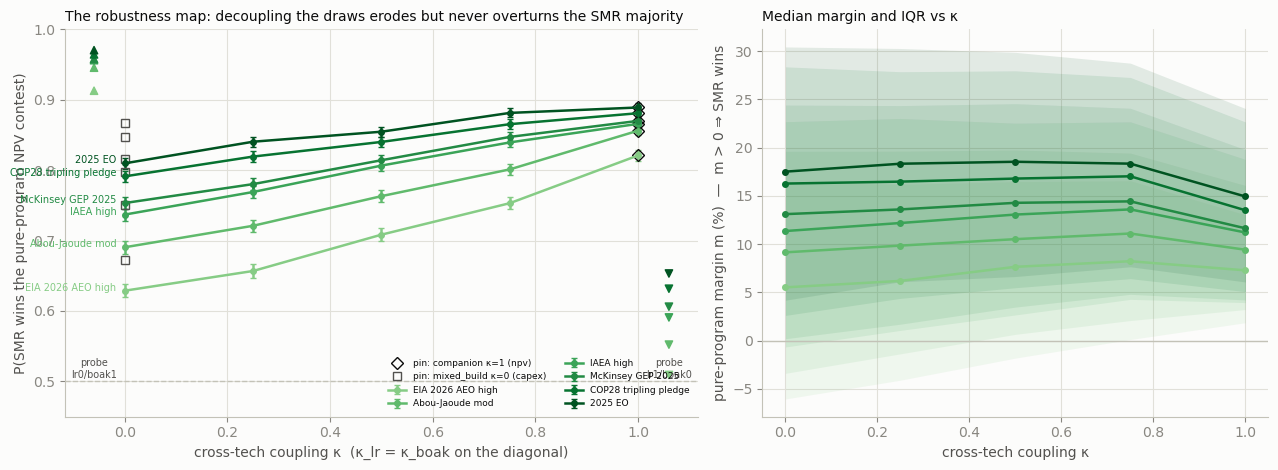

In [12]:
# T5a - robustness map table + headline figure.
def world_of(iid, sched):
    src = INST[iid]["draws_from"] or iid
    return WORLDS_TC[(src, sched)]

def binom_ci(p, n, z=1.96):
    se = np.sqrt(max(p*(1-p), 1e-12)/n)
    return max(0.0, p - z*se), min(1.0, p + z*se)

rm_rows = []
for iid in PRIMARY_IDS + ["scope_a1only", "scope_a2only", "scope_none"]:
    for sched in SCHED_ORDER:
        r = RES[(iid, sched)]
        n = len(r["m_pct"])
        p = float((r["winner"] == "smr").mean())
        lo, hi = binom_ci(p, n)
        lw = r["m_pct"][r["winner"] == "large"]          # large wins: m_pct < 0
        lw_abs = np.abs(lw)
        row = {"cell": iid, "kind": INST[iid]["kind"], "kappa_lr": INST[iid]["k_lr"],
               "kappa_boak": INST[iid]["k_boak"], "schedule": sched, "n": n,
               "P_smr": p, "ci_lo": lo, "ci_hi": hi}
        for q in (5, 25, 50, 75, 95):
            row[f"m_pct_P{q}"] = float(np.percentile(r["m_pct"], q))
        for q in (50, 90, 95):
            row[f"largewin_absm_P{q}"] = float(np.percentile(lw_abs, q)) if len(lw) else np.nan
        row["P_large"] = 1.0 - p
        rm_rows.append(row)
ROBUST = pd.DataFrame(rm_rows)
ROBUST.to_csv(EXPORTS / "robustness_map.csv", index=False)
print(f"wrote {EXPORTS.name}/robustness_map.csv ({len(ROBUST)} rows); binomial CI half-width "
      f"at N={ROBUST['n'].max()}: ~±{100*1.96*np.sqrt(0.25/ROBUST['n'].max()):.1f}pp")

# pins
PIN_K1_NPV = _npv_sum["P(smr) npv"]                       # companion kappa=1, npv object
PIN_K0_CAPEX = pd.read_csv(MC_EXPORTS / "mixed_build" / "verdict_by_schedule.csv",
                           index_col=0)["P(corner winner = SMR)"]  # mixed_build kappa=0, capex

SCHED_COLORS = {s: plt.cm.Greens(x) for s, x in
                zip(SCHED_ORDER, np.linspace(0.45, 0.95, len(SCHED_ORDER)))}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw={"width_ratios": [1.25, 1]})
ax = axes[0]
diag = ROBUST[ROBUST["cell"].isin(KAPPA_ID.values())]
for sched in SCHED_ORDER:
    d = diag[diag["schedule"] == sched].sort_values("kappa_lr")
    ax.errorbar(d["kappa_lr"], d["P_smr"], yerr=[d["P_smr"]-d["ci_lo"], d["ci_hi"]-d["P_smr"]],
                color=SCHED_COLORS[sched], lw=1.8, marker="o", ms=4, capsize=2, label=sched)
    ax.annotate(sched, (0.0, d["P_smr"].iloc[0]), textcoords="offset points",
                xytext=(-6, 0), ha="right", fontsize=7, color=SCHED_COLORS[sched])
ax.plot(np.ones(len(SCHED_ORDER)), [PIN_K1_NPV[s] for s in SCHED_ORDER], ls="",
        marker="D", ms=6, mfc="none", mec=INK, label="pin: companion κ=1 (npv)")
ax.plot(np.zeros(len(SCHED_ORDER)), [PIN_K0_CAPEX[s] for s in SCHED_ORDER], ls="",
        marker="s", ms=6, mfc="none", mec=MUTED, label="pin: mixed_build κ=0 (capex)")
for iid, xoff, mk in [("probe_lr0_boak1", -0.06, "^"), ("probe_lr1_boak0", 1.06, "v")]:
    d = ROBUST[ROBUST["cell"] == iid]
    ax.scatter(np.full(len(d), xoff), d["P_smr"], marker=mk, s=28,
               c=[SCHED_COLORS[s] for s in d["schedule"]], zorder=4)
ax.text(-0.06, 0.505, "probe\nlr0/boak1", ha="center", fontsize=7, color=MUTED)
ax.text(1.06, 0.505, "probe\nlr1/boak0", ha="center", fontsize=7, color=MUTED)
ax.axhline(0.5, color=EDGE_C, lw=1, ls="--")
ax.set_xlabel("cross-tech coupling κ  (κ_lr = κ_boak on the diagonal)")
ax.set_ylabel("P(SMR wins the pure-program NPV contest)")
ax.set_ylim(0.45, 1.0)
ax.set_title("The robustness map: decoupling the draws erodes but never overturns the SMR "
             "majority", fontsize=10, loc="left")
ax.legend(frameon=False, fontsize=6.5, loc="lower right", ncol=2)

ax = axes[1]
for sched in SCHED_ORDER:
    d = diag[diag["schedule"] == sched].sort_values("kappa_lr")
    ax.plot(d["kappa_lr"], d["m_pct_P50"], color=SCHED_COLORS[sched], lw=1.8, marker="o", ms=4)
    ax.fill_between(d["kappa_lr"], d["m_pct_P25"], d["m_pct_P75"],
                    color=SCHED_COLORS[sched], alpha=0.10, lw=0)
ax.axhline(0, color=EDGE_C, lw=1)
ax.set_xlabel("cross-tech coupling κ")
ax.set_ylabel("pure-program margin m (%)  —  m > 0 ⇒ SMR wins")
ax.set_title("Median margin and IQR vs κ", fontsize=10, loc="left")
fig.tight_layout()
fig.savefig(FIGURES / "tc_robustness_map.png", dpi=200, bbox_inches="tight")
plt.show()

In [13]:
# T5b - the large-win tail (C2's home) + ledger stamps C1 and C2.
lw_rows = []
for iid in PRIMARY_IDS:
    for sched in SCHED_ORDER:
        r = RES[(iid, sched)]
        lw = np.abs(r["m_pct"][r["winner"] == "large"])
        lw_rows.append({"cell": iid, "schedule": sched, "n_large_wins": int(len(lw)),
                        "share_large_wins": float(len(lw)/len(r["m_pct"])),
                        **{f"absm_P{q}": (float(np.percentile(lw, q)) if len(lw) else np.nan)
                           for q in (50, 75, 90, 95, 99)},
                        "absm_max": float(lw.max()) if len(lw) else np.nan})
LARGEWIN = pd.DataFrame(lw_rows)
LARGEWIN.to_csv(EXPORTS / "large_win_margins.csv", index=False)

# C1 - majority winner at every primary cell x schedule
prim = ROBUST[ROBUST["kind"] == "primary"]
c1_min = prim.loc[prim["P_smr"].idxmin()]
stamp("C1", (prim["P_smr"] > 0.5).all(),
      region="all primary cells (κ diagonal + split probes), all schedules, NPV object",
      source="T5 robustness_map.csv",
      numbers=f"min P(SMR) = {c1_min['P_smr']:.3f} at ({c1_min['cell']}, {c1_min['schedule']}); "
              f"CI lo {c1_min['ci_lo']:.3f}")

# C2 - large-win margins narrow? (pre-registered to likely FAIL at low kappa)
c2_ok = bool((LARGEWIN["absm_P95"].dropna() < C2_THRESH_PCT).all())
c2_worst = LARGEWIN.loc[LARGEWIN["absm_P95"].idxmax()]
c2_pass_cells = LARGEWIN.groupby("cell")["absm_P95"].max()
stamp("C2", c2_ok,
      region=("all primary cells" if c2_ok else
              f"holds only where P95|m| < {C2_THRESH_PCT}%: "
              f"{sorted(c2_pass_cells[c2_pass_cells < C2_THRESH_PCT].index)}"),
      source="T5 large_win_margins.csv",
      numbers=f"max P95 |m| | large wins = {c2_worst['absm_P95']:.2f}% at "
              f"({c2_worst['cell']}, {c2_worst['schedule']})"
              + ("" if c2_ok else " - tail reported, characterization dropped there"))
print("\nlarge-win tail by cell (P95 of |m|, worst schedule):")
print(c2_pass_cells.round(2).to_string())

[ledger] C1 SUPPORTED - min P(SMR) = 0.509 at (probe_lr1_boak0, EIA 2026 AEO high); CI lo 0.499
[ledger] C2 NOT SUPPORTED - max P95 |m| | large wins = 30.83% at (probe_lr1_boak0, EIA 2026 AEO high) - tail reported, characterization dropped there

large-win tail by cell (P95 of |m|, worst schedule):
cell
k000               28.60
k025               25.31
k050               22.10
k075               16.44
k100                8.77
probe_lr0_boak1     8.12
probe_lr1_boak0    30.83


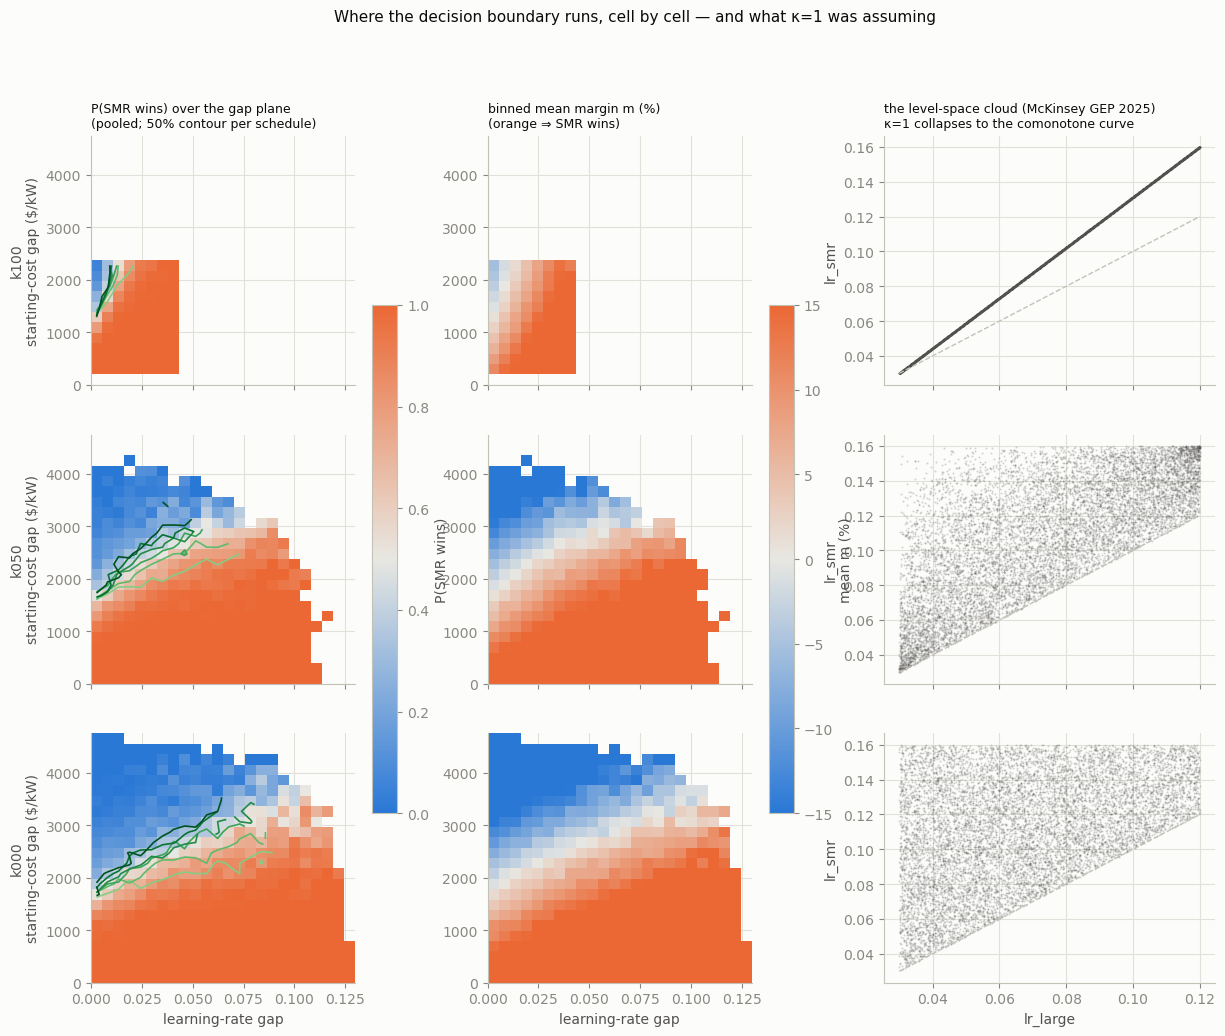

reading: at κ=1 the level cloud is a curve (one dial), so the gap plane is swept by a single degree of freedom; at κ=0 the gaps vary freely - the boundary is what the 50% contours chart, schedule by schedule.


In [14]:
# T5c - boundary maps in gap space + the collapse-at-kappa=1 picture.
GAP_X_EDGES = np.linspace(0.0, TECH["smr"]["lr_hi"] - TECH["large"]["lr_lo"], 25)
GAP_Y_EDGES = np.linspace(0.0, TECH["smr"]["boak_hi"] - TECH["large"]["boak_lo"], 25)
MIN_BIN = 8
_xc = 0.5*(GAP_X_EDGES[:-1] + GAP_X_EDGES[1:])
_yc = 0.5*(GAP_Y_EDGES[:-1] + GAP_Y_EDGES[1:])

def gap_frame(iid, sched):
    w = world_of(iid, sched)
    return pd.DataFrame({"lr_gap": w["lr_smr"] - w["lr_large"],
                         "boak_gap": w["boak_smr"] - w["boak_large"],
                         "smr_win": (RES[(iid, sched)]["winner"] == "smr").astype(float),
                         "m_pct": RES[(iid, sched)]["m_pct"]})

def binned(df, col):
    cnt, _, _ = np.histogram2d(df["lr_gap"], df["boak_gap"], bins=[GAP_X_EDGES, GAP_Y_EDGES])
    tot, _, _ = np.histogram2d(df["lr_gap"], df["boak_gap"], bins=[GAP_X_EDGES, GAP_Y_EDGES],
                               weights=df[col].astype(float))
    with np.errstate(invalid="ignore"):
        return np.where(cnt >= MIN_BIN, tot/cnt, np.nan)

fig, axes = plt.subplots(len(ANCHOR_IDS), 3, figsize=(14.5, 11), sharex="col", sharey="col")
for i, aid in enumerate(ANCHOR_IDS):
    pooled = pd.concat([gap_frame(aid, s) for s in SCHED_ORDER], ignore_index=True)
    ax = axes[i, 0]
    im0 = ax.pcolormesh(GAP_X_EDGES, GAP_Y_EDGES, binned(pooled, "smr_win").T,
                        cmap=CMAP_PSMR, vmin=0, vmax=1, shading="flat")
    for sched in SCHED_ORDER:
        g = binned(gap_frame(aid, sched), "smr_win")
        if np.isfinite(g).sum() > 10:
            ax.contour(_xc, _yc, np.ma.masked_invalid(g.T), levels=[0.5],
                       colors=[SCHED_COLORS[sched]], linewidths=1.2)
    ax.set_ylabel(f"{aid}\nstarting-cost gap ($/kW)")
    if i == 0:
        ax.set_title("P(SMR wins) over the gap plane\n(pooled; 50% contour per schedule)",
                     fontsize=9, loc="left")
    ax = axes[i, 1]
    im1 = ax.pcolormesh(GAP_X_EDGES, GAP_Y_EDGES, binned(pooled, "m_pct").T,
                        cmap=CMAP_PSMR, vmin=-15, vmax=15, shading="flat")
    if i == 0:
        ax.set_title("binned mean margin m (%)\n(orange ⇒ SMR wins)", fontsize=9, loc="left")
    ax = axes[i, 2]
    w = world_of(aid, REP_SCHED)
    ax.scatter(w["lr_large"], w["lr_smr"], s=2, lw=0, color=MUTED, alpha=0.25)
    ax.plot([0.03, 0.12], [0.03, 0.12], color=EDGE_C, lw=1, ls="--")
    ax.set_ylabel("lr_smr")
    if i == 0:
        ax.set_title(f"the level-space cloud ({REP_SCHED})\nκ=1 collapses to the comonotone "
                     "curve", fontsize=9, loc="left")
for j, lbl in enumerate(["learning-rate gap", "learning-rate gap", "lr_large"]):
    axes[-1, j].set_xlabel(lbl)
fig.colorbar(im0, ax=axes[:, 0], shrink=0.6, label="P(SMR wins)")
fig.colorbar(im1, ax=axes[:, 1], shrink=0.6, label="mean m (%)")
fig.suptitle("Where the decision boundary runs, cell by cell — and what κ=1 was assuming",
             y=0.995, fontsize=11)
fig.savefig(FIGURES / "tc_gapplane_boundaries.png", dpi=200, bbox_inches="tight")
plt.show()
print("reading: at κ=1 the level cloud is a curve (one dial), so the gap plane is swept by "
      "a single degree of freedom; at κ=0 the gaps vary freely - the boundary is what the "
      "50% contours chart, schedule by schedule.")

## T6 — Ex-ante commitment analysis

The planner's actual problem: commit to a **fixed, committable mandate** before the
uncertainty resolves. The strategy set is mixed_build's candidate library (corners,
constant mixes, switch families), costed on every draw of every cell — screen reuse, no
optimizer. Metrics per (cell, schedule): **E[cost]**, **P95**, **CVaR₉₅** (matching the
P5/P95 case language), and **E[regret] / max regret vs the best fixed strategy per draw**
— "what the best other committable mandate would have saved." (Regret vs the ex-post
optimum appears only inside T8 as the EVPI integrand.) Then **stochastic dominance**
between the two pure programs: FSD via quantile comparison, SSD via the integrated-CDF
(stop-loss) criterion, with any crossing point reported — SSD everywhere is the
theorem-grade sentence (C4).

In [15]:
# T6a - the ex-ante ranking table + C3.
def cvar(costs, q=0.95):
    """Mean of the worst (highest-cost) (1-q) tail."""
    c = np.sort(np.asarray(costs))
    k = max(1, int(np.ceil((1.0 - q) * len(c))))
    return float(c[-k:].mean())

ex_rows = []
LIB_IDS = [i["iid"] for i in INSTANCES if i["library"]]
for iid in LIB_IDS:
    for sched in SCHED_ORDER:
        r = RES[(iid, sched)]
        costs = score_matrix(r["cand_cap"], r["cand_om"], sched=sched)
        best_fixed_perdraw = costs.min(axis=0)
        for j, nm in enumerate(CAND_NAMES):
            reg = costs[j] - best_fixed_perdraw
            ex_rows.append({"cell": iid, "schedule": sched, "strategy": nm,
                            "E_cost": float(costs[j].mean()),
                            "P95": float(np.percentile(costs[j], 95)),
                            "CVaR95": cvar(costs[j]),
                            "E_regret_pct": float(100*reg.mean()/best_fixed_perdraw.mean()),
                            "max_regret_pct": float(100*reg.max()/best_fixed_perdraw.mean())})
EXANTE = pd.DataFrame(ex_rows)
EXANTE["rank_E"] = EXANTE.groupby(["cell", "schedule"])["E_cost"].rank(method="first")
EXANTE.to_csv(EXPORTS / "exante_ranking.csv", index=False)

emin = EXANTE[EXANTE["rank_E"] == 1].set_index(["cell", "schedule"])["strategy"]
c3_prim = emin.loc[[i for i in PRIMARY_IDS]]
c3_ok = bool((c3_prim == "pure_smr").all())
_viol = c3_prim[c3_prim != "pure_smr"]
stamp("C3", c3_ok,
      region="all primary cells, all schedules, NPV object, fixed-strategy library",
      source="T6 exante_ranking.csv",
      numbers=("pure_smr is the E[cost] minimizer in all "
               f"{len(c3_prim)} (cell, schedule) pairs" if c3_ok else
               f"beaten in {len(_viol)} pairs, e.g. {_viol.head(3).to_dict()}"))

print("\nex-ante top-3 by E[cost] at the anchor cells (representative schedule):")
_top = (EXANTE[(EXANTE["cell"].isin(ANCHOR_IDS)) & (EXANTE["schedule"] == REP_SCHED)
               & (EXANTE["rank_E"] <= 3)]
        .sort_values(["cell", "rank_E"]))
print(_top[["cell", "strategy", "E_cost", "P95", "CVaR95", "E_regret_pct",
            "max_regret_pct"]].to_string(index=False,
      formatters={"E_cost": "{:,.0f}".format, "P95": "{:,.0f}".format,
                  "CVaR95": "{:,.0f}".format, "E_regret_pct": "{:.2f}".format,
                  "max_regret_pct": "{:.2f}".format}))

[ledger] C3 NOT SUPPORTED - beaten in 1 pairs, e.g. {('probe_lr1_boak0', 'EIA 2026 AEO high'): 'pure_large'}

ex-ante top-3 by E[cost] at the anchor cells (representative schedule):
cell            strategy  E_cost     P95  CVaR95 E_regret_pct max_regret_pct
k000            pure_smr 593,017 774,245 813,097         2.97          57.28
k000 large_then_smr_2032 602,869 775,835 812,398         4.68          54.28
k000 smr_then_large_2050 604,811 778,466 815,056         5.02          54.81
k050            pure_smr 586,944 790,350 829,510         1.73          48.47
k050 large_then_smr_2032 597,608 793,794 831,319         3.58          45.97
k050 smr_then_large_2050 599,101 796,630 833,457         3.83          46.51
k100            pure_smr 599,495 825,895 858,598         0.59          14.88
k100 large_then_smr_2032 609,623 828,897 861,320         2.29          14.74
k100 smr_then_large_2050 610,703 830,706 862,841         2.47          14.92


[ledger] C4 NOT SUPPORTED - SSD holds in 1/42 (cell, schedule) pairs; FSD in 0; CVaR95 comparison favors SMR in 29/42


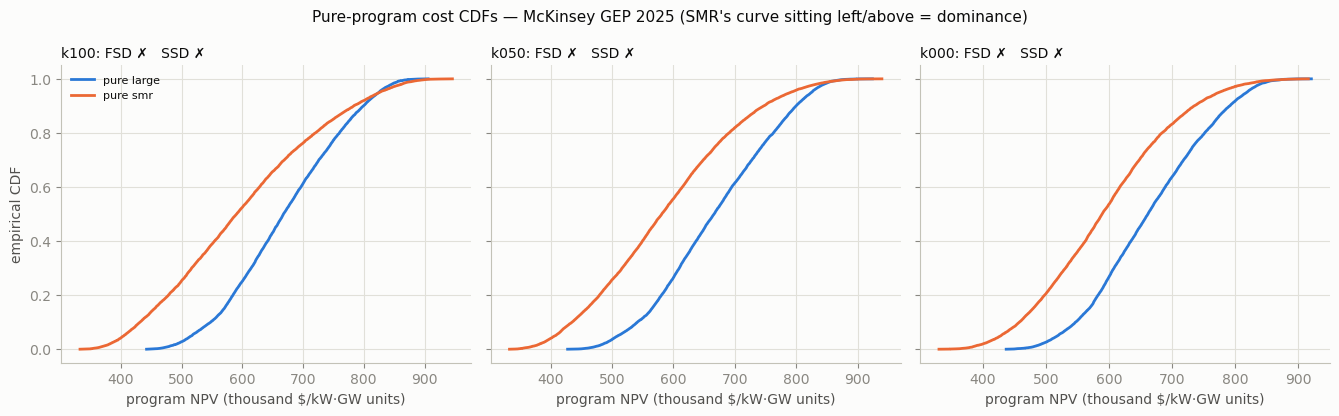

In [16]:
# T6b - stochastic dominance between the pure programs + C4 + figure.
def _stoploss(x_sorted, d):
    """E[(L-d)+] for an empirical distribution, exactly, at thresholds d (vectorized)."""
    n = len(x_sorted)
    suffix = np.concatenate([np.cumsum(x_sorted[::-1])[::-1], [0.0]])
    idx = np.searchsorted(x_sorted, d, side="left")
    return (suffix[idx] - (n - idx) * d) / n

def dominance_tests(Ll, Ls):
    """FSD/SSD of pure-SMR (Ls) over pure-large (Ll), programs as COSTS - both EXACT for
    the empirical distributions. FSD: every order statistic of Ls at or below Ll's (equal
    draw counts). SSD = increasing-convex (stop-loss) order: E[(L-d)+] never larger for
    Ls; the stop-loss function is piecewise linear with kinks only at data points, so
    checking every pooled data value is exact - equivalent to the integrated-CDF
    comparison. One shared tolerance keeps FSD => SSD true numerically.
    Returns (fsd, ssd, crossing d or nan)."""
    ql, qs_ = np.sort(np.asarray(Ll, float)), np.sort(np.asarray(Ls, float))
    assert len(ql) == len(qs_)
    tol = 1e-9 * max(np.abs(ql).max(), 1.0)
    fsd = bool((qs_ <= ql + tol).all())
    grid = np.unique(np.concatenate([ql, qs_]))
    diff = _stoploss(qs_, grid) - _stoploss(ql, grid)   # <= 0 everywhere -> SMR dominates
    ssd = bool((diff <= tol).all())
    crossing = np.nan
    if not ssd:
        crossing = float(grid[int(np.argmax(diff > tol))])
    return fsd, ssd, crossing

dom_rows = []
for iid in PRIMARY_IDS:
    for sched in SCHED_ORDER:
        r = RES[(iid, sched)]
        fsd, ssd, crossing = dominance_tests(r["Rl"], r["Rs"])
        dom_rows.append({"cell": iid, "schedule": sched, "FSD_smr": fsd, "SSD_smr": ssd,
                         "crossing_cost": crossing,
                         "crossing_pct_of_median": (100*crossing/np.median(r["Rs"])
                                                    if np.isfinite(crossing) else np.nan),
                         "CVaR95_smr_le_large": cvar(r["Rs"]) <= cvar(r["Rl"]),
                         "E_smr_le_large": float(r["Rs"].mean()) <= float(r["Rl"].mean())})
DOM = pd.DataFrame(dom_rows)
DOM.to_csv(EXPORTS / "dominance_tests.csv", index=False)

c4_ok = bool(DOM["SSD_smr"].all())
_fails = DOM[~DOM["SSD_smr"]]
_cvar_ok = bool(DOM["CVaR95_smr_le_large"].all())
stamp("C4", c4_ok,
      region=("all primary cells" if c4_ok else
              f"SSD fails in {len(_fails)}/{len(DOM)} pairs; "
              + ("downgrade holds: CVaR95(smr) <= CVaR95(large) everywhere"
                 if _cvar_ok else "CVaR95 downgrade also fails somewhere")),
      source="T6 dominance_tests.csv",
      numbers=f"SSD holds in {int(DOM['SSD_smr'].sum())}/{len(DOM)} (cell, schedule) pairs; "
              f"FSD in {int(DOM['FSD_smr'].sum())}; CVaR95 comparison favors SMR in "
              f"{int(DOM['CVaR95_smr_le_large'].sum())}/{len(DOM)}")

fig, axes = plt.subplots(1, len(ANCHOR_IDS), figsize=(13.5, 4.2), sharey=True)
for ax, aid in zip(axes, ANCHOR_IDS):
    r = RES[(aid, REP_SCHED)]
    for tech, arr in (("large", r["Rl"]), ("smr", r["Rs"])):
        xs = np.sort(arr)
        ax.plot(xs/1e3, np.linspace(0, 1, len(xs)), color=COL[tech], lw=2,
                label=f"pure {tech}")
    row = DOM[(DOM["cell"] == aid) & (DOM["schedule"] == REP_SCHED)].iloc[0]
    ax.set_title(f"{aid}: FSD {'✓' if row['FSD_smr'] else '✗'}   SSD "
                 f"{'✓' if row['SSD_smr'] else '✗'}", fontsize=10, loc="left")
    ax.set_xlabel("program NPV (thousand $/kW·GW units)")
axes[0].set_ylabel("empirical CDF")
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle(f"Pure-program cost CDFs — {REP_SCHED} (SMR's curve sitting left/above = "
             "dominance)", fontsize=11)
fig.tight_layout()
fig.savefig(FIGURES / "tc_dominance_cdfs.png", dpi=200, bbox_inches="tight")
plt.show()

## T7 — Adaptive strategies: the option value of sequencing

A **two-stage bound, no filtration modeling** (ratified conventions). Stage boundary
**2036** — the earliest year own-build realized costs could exist (2031–35 SMR builds at
~43–55 months complete ~2035); an early boundary *maximizes* the option value, so a small
bound here is conservative — small at 2036 ⇒ smaller at any later boundary. Stage 1
commits one technology for 2031–2035. At 2036 the planner gets either **(i) no
information** — continuations are exactly the fixed strategies of T6 — or **(ii) perfect
information** — the best continuation from **{stay; full switch to the other tech in year
τ}, τ ∈ 2036–2045**, for either stage-1 choice. The gap between (ii)'s expectation and
the best fixed strategy's expectation is an **upper bound on the value of adaptive
sequencing** (C5). The noisy-signal middle tier gets built only if C5 fails.

[ledger] C5 NOT SUPPORTED - max PI option value = 5.882% of expected program cost at (probe_lr1_boak0, EIA 2026 AEO high) (threshold 1.0%) - noisy-signal tier now owed


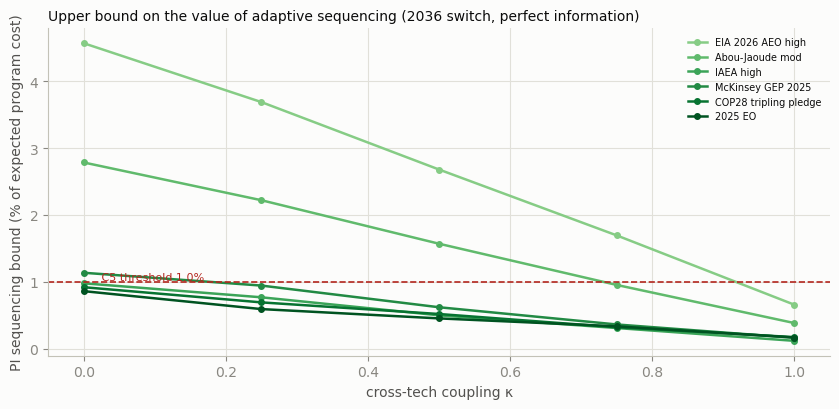

In [17]:
# T7 - the perfect-information sequencing bound + C5 + figure.
SWITCH_TAUS = [y for y in BUILD_YEARS if 2036 <= y <= 2045]
CONT_L = [I_PL] + [CAND_NAMES.index(f"large_then_smr_{y}") for y in SWITCH_TAUS]
CONT_S = [I_PS] + [CAND_NAMES.index(f"smr_then_large_{y}") for y in SWITCH_TAUS]

ad_rows = []
for iid in PRIMARY_IDS:
    for sched in SCHED_ORDER:
        r = RES[(iid, sched)]
        costs = score_matrix(r["cand_cap"], r["cand_om"], sched=sched)
        e_best_fixed = float(costs.mean(axis=1).min())
        v_pi = min(float(costs[CONT_L].min(axis=0).mean()),
                   float(costs[CONT_S].min(axis=0).mean()))
        bound_raw = e_best_fixed - v_pi
        ad_rows.append({"cell": iid, "schedule": sched, "E_best_fixed": e_best_fixed,
                        "V_perfect_info": v_pi, "bound_raw": bound_raw,
                        "bound_pct": 100.0*max(0.0, bound_raw)/e_best_fixed})
ADAPT = pd.DataFrame(ad_rows)
ADAPT.to_csv(EXPORTS / "adaptive_value.csv", index=False)

c5_worst = ADAPT.loc[ADAPT["bound_pct"].idxmax()]
c5_ok = bool((ADAPT["bound_pct"] < C5_THRESH_PCT).all())
stamp("C5", c5_ok,
      region="all primary cells, all schedules; 2036 boundary, switch library τ∈2036–2045",
      source="T7 adaptive_value.csv",
      numbers=f"max PI option value = {c5_worst['bound_pct']:.3f}% of expected program cost "
              f"at ({c5_worst['cell']}, {c5_worst['schedule']}) "
              f"(threshold {C5_THRESH_PCT}%)"
              + ("" if c5_ok else " - noisy-signal tier now owed"))

fig, ax = plt.subplots(figsize=(8.5, 4.2))
for sched in SCHED_ORDER:
    d = ADAPT[(ADAPT["schedule"] == sched)
              & (ADAPT["cell"].isin(KAPPA_ID.values()))].copy()
    d["kappa"] = d["cell"].map({v: k for k, v in KAPPA_ID.items()})
    d = d.sort_values("kappa")
    ax.plot(d["kappa"], d["bound_pct"], color=SCHED_COLORS[sched], lw=1.8, marker="o",
            ms=4, label=sched)
ax.axhline(C5_THRESH_PCT, color="#b3261e", lw=1.2, ls="--")
ax.text(0.02, C5_THRESH_PCT, f" C5 threshold {C5_THRESH_PCT}%", va="bottom", fontsize=8,
        color="#b3261e")
ax.set_xlabel("cross-tech coupling κ")
ax.set_ylabel("PI sequencing bound (% of expected program cost)")
ax.set_title("Upper bound on the value of adaptive sequencing (2036 switch, perfect "
             "information)", fontsize=10, loc="left")
ax.legend(frameon=False, fontsize=7)
fig.tight_layout()
fig.savefig(FIGURES / "tc_adaptive_bound.png", dpi=200, bbox_inches="tight")
plt.show()

## T8 — Value of information (EVPI)

**Total EVPI** per (cell, schedule): the gap between the best fixed strategy's expected
cost and the expectation of the per-draw ex-post best fixed strategy — what a clairvoyant
mandate-setter would save. **Per-parameter partial EVPI** by conditioning on the existing
draws (bin the parameter, pick the best fixed strategy within each bin, average): which
unknown — the anchor gap, the learning-rate gap, the experience-base convention, or **κ
itself** — most changes the *decision*. This backfills T1's sensitivity column.

T1 sensitivity column backfilled. Mean partial EVPI (% of best fixed E[cost]):
parameter
boak_gap     1.510
conv_full    0.011
lr_gap       0.289
kappa itself (pooled diagonal): 0.000%


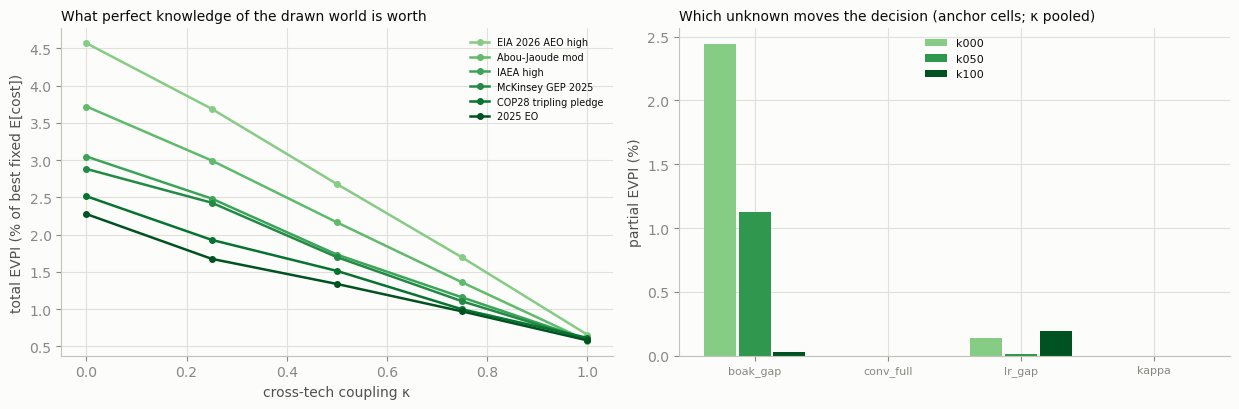

In [18]:
# T8 - EVPI total + partial + figure; backfills T1.
evpi_rows, part_rows = [], []
PARTIAL_PARAMS = ["boak_gap", "lr_gap", "conv_full"]
N_BINS = 10
for iid in PRIMARY_IDS:
    for sched in SCHED_ORDER:
        r = RES[(iid, sched)]
        costs = score_matrix(r["cand_cap"], r["cand_om"], sched=sched)
        e_fixed = costs.mean(axis=1)
        best_e = float(e_fixed.min())
        evpi = best_e - float(costs.min(axis=0).mean())
        evpi_rows.append({"cell": iid, "schedule": sched, "EVPI": evpi,
                          "EVPI_pct": 100.0*evpi/best_e})
        w = world_of(iid, sched)
        vals = {"boak_gap": (w["boak_smr"] - w["boak_large"]).to_numpy(),
                "lr_gap": (w["lr_smr"] - w["lr_large"]).to_numpy(),
                "conv_full": w["conv_full"].to_numpy()}
        for pname, v in vals.items():
            if pname == "conv_full":
                bins = v.astype(int)
            else:
                edges = np.quantile(v, np.linspace(0, 1, N_BINS + 1))
                bins = np.clip(np.searchsorted(edges, v, side="right") - 1, 0, N_BINS - 1)
            e_cond = 0.0
            for b in np.unique(bins):
                m = bins == b
                e_cond += m.mean() * float(costs[:, m].mean(axis=1).min())
            part_rows.append({"cell": iid, "schedule": sched, "parameter": pname,
                              "partial_EVPI_pct": 100.0*max(0.0, best_e - e_cond)/best_e})
EVPI_TOT = pd.DataFrame(evpi_rows)
EVPI_TOT.to_csv(EXPORTS / "evpi_total.csv", index=False)

# partial EVPI of kappa itself: pooled over the diagonal cells (equal cell weights)
for sched in SCHED_ORDER:
    e_by_cell = {}
    for k, iid in KAPPA_ID.items():
        r = RES[(iid, sched)]
        e_by_cell[iid] = score_matrix(r["cand_cap"], r["cand_om"], sched=sched).mean(axis=1)
    E_pool = np.mean([e_by_cell[i] for i in KAPPA_ID.values()], axis=0)
    best_pool = float(E_pool.min())
    e_cond = float(np.mean([e_by_cell[i].min() for i in KAPPA_ID.values()]))
    part_rows.append({"cell": "pooled_diagonal", "schedule": sched, "parameter": "kappa",
                      "partial_EVPI_pct": 100.0*max(0.0, best_pool - e_cond)/best_pool})
EVPI_PART = pd.DataFrame(part_rows)
EVPI_PART.to_csv(EXPORTS / "evpi_partial.csv", index=False)

# backfill T1's sensitivity column with the decision-sensitivity ranking
_pe = EVPI_PART[EVPI_PART["parameter"] != "kappa"].groupby("parameter")["partial_EVPI_pct"].mean()
_pk = EVPI_PART[EVPI_PART["parameter"] == "kappa"]["partial_EVPI_pct"].mean()
_sens_map = {"boak_large": "boak_gap", "boak_smr": "boak_gap",
             "lr_large": "lr_gap", "lr_smr": "lr_gap", "conv_full": "conv_full"}
for row_name, pname in _sens_map.items():
    MARGINAL_TABLE.loc[row_name, "decision_sensitivity"] = \
        f"partial EVPI {_pe[pname]:.2f}% (C3 decision layer)"
print("T1 sensitivity column backfilled. Mean partial EVPI (% of best fixed E[cost]):")
print(_pe.round(3).to_string())
print(f"kappa itself (pooled diagonal): {_pk:.3f}%")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
ax = axes[0]
for sched in SCHED_ORDER:
    d = EVPI_TOT[(EVPI_TOT["schedule"] == sched)
                 & (EVPI_TOT["cell"].isin(KAPPA_ID.values()))].copy()
    d["kappa"] = d["cell"].map({v: k for k, v in KAPPA_ID.items()})
    d = d.sort_values("kappa")
    ax.plot(d["kappa"], d["EVPI_pct"], color=SCHED_COLORS[sched], lw=1.8, marker="o", ms=4,
            label=sched)
ax.set_xlabel("cross-tech coupling κ")
ax.set_ylabel("total EVPI (% of best fixed E[cost])")
ax.set_title("What perfect knowledge of the drawn world is worth", fontsize=10, loc="left")
ax.legend(frameon=False, fontsize=7)
ax = axes[1]
_bar = (EVPI_PART[EVPI_PART["cell"].isin(ANCHOR_IDS)]
        .groupby(["parameter", "cell"])["partial_EVPI_pct"].mean().unstack())
_bar.loc["kappa"] = np.nan
_bar.loc["kappa", ANCHOR_IDS[0]] = _pk
x = np.arange(len(_bar))
for j, aid in enumerate(_bar.columns):
    ax.bar(x + (j - 1)*0.26, _bar[aid], width=0.24, color=plt.cm.Greens(0.45 + 0.25*j),
           label=aid)
ax.set_xticks(x)
ax.set_xticklabels(_bar.index, fontsize=8)
ax.set_ylabel("partial EVPI (%)")
ax.set_title("Which unknown moves the decision (anchor cells; κ pooled)", fontsize=10,
             loc="left")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "tc_evpi.png", dpi=200, bbox_inches="tight")
plt.show()

## T9 — Structural sensitivities

At the three anchor cells unless noted: the **learning floor** (fixed φ ∈ {0, 0.3, 0.5},
`OCC_t ≥ φ·BOAK` per tech — floorless / mild / binding; φ = 0.5 is the headline stress:
"even if half the anchor cost is irreducible…"; calibration context: the meta-analysis's
own 2050 advanced endpoints sit at ~0.20–0.36× (SMR) and ~0.29–0.43× (large) of anchors,
so 0.5 genuinely bites; φ = 0.75 was rejected — it degenerates the comparison to anchors
plus financing; a *drawn* φ was rejected — it muddies attribution with no evidence to
elicit from); the **CES grid** {−1, 0, 1} and the **routing variant** (S14 own-channel
upper bound) folded in as one-liners pointing at the existing analyses; and the T3
**FLEX_CREDIT / ITC / capex-object** results reported alongside. C6 stamps here.

In [19]:
# T9 - structural sensitivities + the C6 stress-survival stamp.
print("Learning floor (P(SMR wins, npv) per anchor cell, min..max across schedules):")
floor_p = {}
for aid in ANCHOR_IDS:
    for phi, src in [(0.0, aid), (0.3, f"floor030@{aid}"), (0.5, f"floor050@{aid}")]:
        ps = [float((RES[(src, s)]["winner"] == "smr").mean()) for s in SCHED_ORDER]
        floor_p[(aid, phi)] = ps
        print(f"  {aid} phi={phi:.1f}: {min(ps):.3f} .. {max(ps):.3f}")

print("\nCES substitution grid (engine override, anchors, pooled schedules) - the drawn "
      "ces_rho stratification already spans this; shown as a one-line decomposition:")
for rho in CES_RHO_GRID:
    ps = []
    for aid in ANCHOR_IDS:
        for sched in SCHED_ORDER:
            w = world_of(aid, sched)
            skv = SKV_ANCHOR[(aid, sched)]
            cl, ol = program_components(w, sched, P_LARGE, S_KV=skv, ces_rho=float(rho))
            cs, os_ = program_components(w, sched, P_SMR, S_KV=skv, ces_rho=float(rho))
            ps.append(float(((cs + os_) < (cl + ol)).mean()))
    print(f"  ces_rho = {rho:+.0f}: P(SMR) {min(ps):.3f} .. {max(ps):.3f}")

_rt = pd.read_csv(MC_EXPORTS / "routing_sensitivity.csv")
print(f"\nRouting variant (S14 own-channel upper bound): NOT an engine path here - the "
      f"cross-firm placement is the production engine (2026-08-06 round-trip decision); "
      f"see mc S14's routing_sensitivity.csv ({len(_rt)} rows) for the bound.")

print("\nCost-object variants at the anchors (from T3/T4 algebra):")
for lbl, _ in _costobj_specs:
    ps = [p for aid in ANCHOR_IDS for p in COSTOBJ_P[(lbl, aid)].values()]
    print(f"  {lbl:7s}: P(SMR) {min(ps):.3f} .. {max(ps):.3f}")

# --- C6: C1 and C3 survive each single stress at the anchor cells ---
c6_rows = []
def _c1c3_at(iid, label):
    ps = [float((RES[(iid, s)]["winner"] == "smr").mean()) for s in SCHED_ORDER]
    if INST[iid]["library"]:
        e_ok = all(emin.loc[(iid, s)] == "pure_smr" for s in SCHED_ORDER)
    else:
        e_ok = None
    c6_rows.append({"stress": label, "cell": iid, "min_P_smr": min(ps),
                    "max_P_smr": max(ps), "C1_holds": min(ps) > 0.5, "C3_holds": e_ok})

for var, lab in [("ob", "OB x1.5"), ("neglr_sym", "NEGLR sym -15%"),
                 ("neglr_large", "NEGLR large_only -15%")]:
    for aid in ANCHOR_IDS:
        _c1c3_at(f"{var}@{aid}", lab)
for aid in ANCHOR_IDS:
    _c1c3_at(f"floor050@{aid}", "floor phi=0.5")
for lbl, lab in [("flex25", "FLEX 25"), ("flex50", "FLEX 50"),
                 ("capex", "capex object"), ("itc30", "ITC 30%")]:
    for aid in ANCHOR_IDS:
        ps = list(COSTOBJ_P[(lbl, aid)].values())
        e_ok = all(v == "pure_smr" for v in COSTOBJ_EMIN[(lbl, aid)].values())
        c6_rows.append({"stress": lab, "cell": aid, "min_P_smr": min(ps),
                        "max_P_smr": max(ps), "C1_holds": min(ps) > 0.5, "C3_holds": e_ok})
C6_TAB = pd.DataFrame(c6_rows)
_c6_break = C6_TAB[(~C6_TAB["C1_holds"]) | (C6_TAB["C3_holds"] == False)]
c6_ok = len(_c6_break) == 0
stamp("C6", c6_ok,
      region="anchor kappa cells {1, 0.5, 0} x single stresses "
             "{OB, NEGLR sym, NEGLR large_only, phi=0.5, FLEX, capex, ITC}",
      source="T9 (stress cells + cost-object algebra)",
      numbers=("C1 and C3 survive every stress cell; min P(SMR) across all = "
               f"{C6_TAB['min_P_smr'].min():.3f}" if c6_ok else
               "breaking cells: " + "; ".join(f"{r.stress}@{r.cell} "
               f"(minP={r.min_P_smr:.3f}, C3={r.C3_holds})"
               for r in _c6_break.itertuples())))
print("\nstress survival table:")
print(C6_TAB.to_string(index=False, formatters={"min_P_smr": "{:.3f}".format,
                                                "max_P_smr": "{:.3f}".format}))

# Export the stress ladder (+ baseline and floor phi=0.3 context rows, which are not C6
# stresses and therefore sit outside the stamp above) for downstream consumers.
_extra = []
for aid in ANCHOR_IDS:
    ps = [float((RES[(aid, s)]["winner"] == "smr").mean()) for s in SCHED_ORDER]
    _extra.append({"stress": "baseline (default)", "cell": aid, "min_P_smr": min(ps),
                   "max_P_smr": max(ps), "C1_holds": min(ps) > 0.5,
                   "C3_holds": all(emin.loc[(aid, s)] == "pure_smr" for s in SCHED_ORDER)})
    ps = [float((RES[(f"floor030@{aid}", s)]["winner"] == "smr").mean())
          for s in SCHED_ORDER]
    _extra.append({"stress": "floor phi=0.3", "cell": f"floor030@{aid}",
                   "min_P_smr": min(ps), "max_P_smr": max(ps),
                   "C1_holds": min(ps) > 0.5, "C3_holds": None})
STRESS_EXPORT = pd.concat([pd.DataFrame(_extra), C6_TAB], ignore_index=True)
STRESS_EXPORT.to_csv(EXPORTS / "stress_survival.csv", index=False)
print(f"wrote {EXPORTS.name}/stress_survival.csv ({len(STRESS_EXPORT)} rows)")

Learning floor (P(SMR wins, npv) per anchor cell, min..max across schedules):
  k100 phi=0.0: 0.821 .. 0.889
  k100 phi=0.3: 0.821 .. 0.889
  k100 phi=0.5: 0.821 .. 0.878
  k050 phi=0.0: 0.708 .. 0.855
  k050 phi=0.3: 0.708 .. 0.854
  k050 phi=0.5: 0.708 .. 0.805
  k000 phi=0.0: 0.629 .. 0.810
  k000 phi=0.3: 0.629 .. 0.809
  k000 phi=0.5: 0.629 .. 0.747

CES substitution grid (engine override, anchors, pooled schedules) - the drawn ces_rho stratification already spans this; shown as a one-line decomposition:


  ces_rho = -1: P(SMR) 0.659 .. 0.907


  ces_rho = +0: P(SMR) 0.641 .. 0.898


  ces_rho = +1: P(SMR) 0.584 .. 0.863

Routing variant (S14 own-channel upper bound): NOT an engine path here - the cross-firm placement is the production engine (2026-08-06 round-trip decision); see mc S14's routing_sensitivity.csv (4 rows) for the bound.

Cost-object variants at the anchors (from T3/T4 algebra):
  capex  : P(SMR) 0.671 .. 0.893
  itc30  : P(SMR) 0.616 .. 0.890
  flex25 : P(SMR) 0.691 .. 0.940
  flex50 : P(SMR) 0.745 .. 0.971
[ledger] C6 NOT SUPPORTED - breaking cells: OB x1.5@ob@k100 (minP=0.002, C3=False); OB x1.5@ob@k050 (minP=0.126, C3=False); OB x1.5@ob@k000 (minP=0.229, C3=False); NEGLR sym -15%@neglr_sym@k100 (minP=0.454, C3=False)

stress survival table:
               stress             cell min_P_smr max_P_smr  C1_holds  C3_holds
              OB x1.5          ob@k100     0.002     0.207     False     False
              OB x1.5          ob@k050     0.126     0.420     False     False
              OB x1.5          ob@k000     0.229     0.494     False     F

In [20]:
# C7 - scope: the ordering 2x2 at kappa=0, reported once as the boundary of validity.
scope_tab = []
for iid, lab in [("k000", "A1+A2 (production frame)"), ("scope_a1only", "A1 only"),
                 ("scope_a2only", "A2 only"), ("scope_none", "neither")]:
    ps = [float((RES[(iid, s)]["winner"] == "smr").mean()) for s in SCHED_ORDER]
    scope_tab.append({"orthant": lab, "P_smr_min": min(ps), "P_smr_max": max(ps)})
SCOPE_TAB = pd.DataFrame(scope_tab).set_index("orthant")
print("scope cells at kappa=0 (reported once; NO claims are made outside A1+A2):")
print(SCOPE_TAB.round(3).to_string())
stamp("C7", True,
      region="claims C1-C6 conditional on the ordered orthant (A1: SMR pricier at anchor, "
             "A2: SMR faster-learning) - the economic premise of the SMR proposition",
      source="T9 scope cells",
      numbers="outside the orthant P(SMR) spans "
              f"{SCOPE_TAB['P_smr_min'].min():.3f}..{SCOPE_TAB['P_smr_max'].max():.3f}; "
              "A2 off = modularity premise fails; stated in methods as bounding all claims")

scope cells at kappa=0 (reported once; NO claims are made outside A1+A2):
                          P_smr_min  P_smr_max
orthant                                       
A1+A2 (production frame)      0.629      0.810
A1 only                       0.503      0.623
A2 only                       0.730      0.858
neither                       0.616      0.696
[ledger] C7 SUPPORTED - outside the orthant P(SMR) spans 0.503..0.858; A2 off = modularity premise fails; stated in methods as bounding all claims


## T10 — Validation

Hindcast positions restated per marginal variant (NEGLR's *point* is to bring France's
−15%/doubling inside support; the US −30% remains outside by ratified choice — it embeds
the post-TMI shock; Korea should stay in the upper tail), then the MC-error appendix:
binomial CIs on every reported probability, bootstrap CIs on the quantile/CVaR metrics,
and the seed-stream audit.

In [21]:
# T10a - hindcast positions per marginal variant.
HINDCASTS = [("Korea 1972-2008 (Lovering et al. 2016)", 0.13, "smr"),
             ("France 1970s-1990s (Grubler 2010)", -0.15, "large"),
             ("US 1970s-1980s (Eash-Gates et al. 2020)", -0.30, "large")]
_hc_ref = pd.read_csv(MC_EXPORTS / "hindcast_positions.csv", index_col=0)

def lr_position(obs, tech, variant):
    lo, hi = LR_RANGE[tech]
    if variant == "neglr_sym" or (variant == "neglr_large" and tech == "large"):
        lo = NEGLR_LO
    if obs < lo:
        return "BELOW support"
    if obs > hi:
        return "ABOVE support"
    if variant == "pert":
        q = stats.beta.cdf((obs - lo)/(hi - lo), 3.0, 3.0)   # midpoint-mode PERT
    else:
        q = (obs - lo)/(hi - lo)
    return f"P{100*q:.0f}"

hc_rows = []
for name, obs, tech in HINDCASTS:
    row = {"case": name, "observed": obs, "range": tech}
    for var in VARIANTS:
        row[var] = lr_position(obs, tech, var)
    hc_rows.append(row)
HC = pd.DataFrame(hc_rows).set_index("case")
print("hindcast positions per marginal variant (production reference: "
      "exports/hindcast_positions.csv):")
print(HC.to_string())
assert HC.loc[HINDCASTS[1][0], "neglr_sym"] != "BELOW support", \
    "NEGLR must bring France inside support - that is its point"
assert HC.loc[HINDCASTS[2][0], "default"] == "BELOW support", \
    "US -30% must remain outside by ratified choice"
print("\nchecks: France -15% inside support under NEGLR (its point); US -30% outside "
      "everywhere except the NEGLR endpoint itself (post-TMI shock, excluded by choice); "
      f"Korea {HC.loc[HINDCASTS[0][0], 'default']} under the default (reference: "
      f"{_hc_ref.loc[HINDCASTS[0][0], 'position']}).")

hindcast positions per marginal variant (production reference: exports/hindcast_positions.csv):
                                         observed  range        default             ob      neglr_sym    neglr_large           pert
case                                                                                                                               
Korea 1972-2008 (Lovering et al. 2016)       0.13    smr            P77            P77            P90            P77            P92
France 1970s-1990s (Grubler 2010)           -0.15  large  BELOW support  BELOW support             P0             P0  BELOW support
US 1970s-1980s (Eash-Gates et al. 2020)     -0.30  large  BELOW support  BELOW support  BELOW support  BELOW support  BELOW support

checks: France -15% inside support under NEGLR (its point); US -30% outside everywhere except the NEGLR endpoint itself (post-TMI shock, excluded by choice); Korea P77 under the default (reference: P77 of the sampled range).


In [22]:
# T10b - MC-error appendix + seed-stream audit.
rng_boot = rng_stream("tccomp/qa/bootstrap")
B = 300
boot_rows = []
for aid in ANCHOR_IDS:
    for sched in SCHED_ORDER:
        r = RES[(aid, sched)]
        n = len(r["Rs"])
        idx = rng_boot.integers(0, n, (B, n))
        for tech, arr in (("large", r["Rl"]), ("smr", r["Rs"])):
            cv = np.array([cvar(arr[i]) for i in idx])
            p95 = np.percentile(arr[idx], 95, axis=1)
            boot_rows.append({"cell": aid, "schedule": sched, "program": tech,
                              "CVaR95": cvar(arr),
                              "CVaR95_ci_lo": float(np.percentile(cv, 2.5)),
                              "CVaR95_ci_hi": float(np.percentile(cv, 97.5)),
                              "P95": float(np.percentile(arr, 95)),
                              "P95_ci_lo": float(np.percentile(p95, 2.5)),
                              "P95_ci_hi": float(np.percentile(p95, 97.5))})
BOOT = pd.DataFrame(boot_rows)
_rel = ((BOOT["CVaR95_ci_hi"] - BOOT["CVaR95_ci_lo"]) / BOOT["CVaR95"]).max()
print(f"bootstrap ({B} resamples): worst relative 95% CI width on CVaR95 = {100*_rel:.2f}% "
      "- the risk metrics are MC-stable")
print(f"binomial CIs: every P in robustness_map.csv carries its CI; max half-width "
      f"{100*(ROBUST['ci_hi'] - ROBUST['P_smr']).max():.2f}pp")

# seed-stream audit: every stream requested exactly once, all tccomp/-prefixed. (A
# duplicate is only expected if a cell was re-run interactively - warn, don't crash.)
_dup = pd.Series(STREAMS_USED).value_counts()
if (_dup > 1).any():
    print(f"seed-stream audit WARNING: streams requested more than once (interactive "
          f"re-run?): {_dup[_dup > 1].index.tolist()}")
print(f"seed-stream audit: {len(STREAMS_USED)} named streams "
      f"({int((_dup == 1).sum())} unique), all "
      f"prefixed tccomp/, master seed {MASTER_SEED}; the kappa=1 cell uses the companion "
      "MC's own frozen draws (no new stream by design)")

bootstrap (300 resamples): worst relative 95% CI width on CVaR95 = 1.43% - the risk metrics are MC-stable
binomial CIs: every P in robustness_map.csv carries its CI; max half-width 0.98pp
seed-stream audit: 103 named streams (103 unique), all prefixed tccomp/, master seed 20260715; the kappa=1 cell uses the companion MC's own frozen draws (no new stream by design)


## QA suite

One check per cell, each announcing PASS or FAIL. QA-A/B pin the engine; QA-C/D/E pin the
dependence cells to the three companion notebooks; QA-F/G/H validate the new machinery
(marginal invariance, blended-O&M affinity, dominance logic, floors). Pins that require
the full 10,000-draw npz are gated on a full-size run (a smoke run reports SKIPPED).

In [23]:
# QA-A - engine parity: the production experience_channels/occ_paths_ces (with their
# hot-loop conveniences at neutral settings) reproduce the companion notebook's engine
# BIT-FOR-BIT. The companion's exact function bodies are pasted here as the reference
# (mc_cost_trajectories.ipynb S5), and the ReEDS financing pin is re-asserted.
def _experience_channels_companion(world, tech, n_us, n_oth=None):
    n = len(world)
    u_r = np.repeat(world["u"].values[:, None], len(REGIONS), axis=1)
    gi = np.clip(np.rint(u_r * (len(U_GRID)-1)).astype(int), 0, len(U_GRID)-1)
    S_kv = np.zeros((n, T))
    for j, r in enumerate(REGIONS):
        S_kv += THETA_KV[r] * REGION_STOCK[r][gi[:, j], :]
    S_kv = lag1(S_kv)
    N_us = lag1(np.broadcast_to(np.asarray(n_us, float), (n, T)))
    conv = world["conv_full"].values[:, None].astype(float)
    m = world["n_vendors"].values[:, None].astype(float)
    s = world["s"].values[:, None]
    hist_us = HIST_UNITS["US"] if tech == "large" else 0.0
    own0 = N_BOAK_UNITS + conv*hist_us/m
    own = own0 + N_us/m
    oth = (m-1.0)*own0 + N_us*(m-1.0)/m \
          + s*(conv*H_ALL_W + S_kv)
    if n_oth is not None:
        x = world[X_IN_COL[tech]].values[:, None]
        oth = oth + x*lag1(np.broadcast_to(np.asarray(n_oth, float), (n, T)))
    return own, oth

def _occ_paths_ces_companion(world, tech, n_us, n_oth=None, ces_rho=None):
    own, oth = _experience_channels_companion(world, tech, n_us, n_oth=n_oth)
    lr = world[f"lr_{tech}"].values[:, None]
    b1, b2 = np.log2(1.0 - lr), np.log2(1.0 - OMEGA*lr)
    b, w = -(b1 + b2), b1/(b1 + b2)
    rho = world["ces_rho"].values if ces_rho is None else np.full(len(world), float(ces_rho))
    rho = rho[:, None]
    geo = np.abs(rho) < CES_EPS
    lnO, lnA = np.log(own), np.log(oth)
    with np.errstate(over="raise"):
        lnE = np.where(geo, w*lnO + (1.0-w)*lnA,
                       lnO + np.log1p((1.0-w)*np.expm1(np.where(geo, 0.0, rho)*(lnA - lnO)))
                           / np.where(geo, 1.0, rho))
    return world[f"boak_{tech}"].values[:, None] * np.exp(-b*(lnE - lnE[:, [yi(ANCHOR)]]))

_wq = world_of("k100", REP_SCHED).head(2000)
_skvq = intl_stock(_wq)
for tech in TECH:
    n_us = np.cumsum(GW_ADD[REP_SCHED]) / TECH[tech]["unit_gw"]
    n_oth = np.cumsum(GW_ADD[REP_SCHED]) / TECH[OTHER_TECH[tech]]["unit_gw"]
    for kwargs in ({}, {"n_oth": n_oth}):
        own_a, oth_a = experience_channels(_wq, tech, n_us, **kwargs)
        own_b, oth_b = experience_channels(_wq, tech, n_us, S_KV=_skvq,
                                           x_in=_wq[X_IN_COL[tech]].values, **kwargs)
        own_c, oth_c = _experience_channels_companion(_wq, tech, n_us, **kwargs)
        assert np.array_equal(own_a, own_c) and np.array_equal(oth_a, oth_c), (tech, sorted(kwargs))
        assert np.array_equal(own_b, own_c) and np.array_equal(oth_b, oth_c), (tech, sorted(kwargs))
        occ_a = occ_paths_ces(_wq, tech, n_us, **kwargs)
        occ_c = _occ_paths_ces_companion(_wq, tech, n_us, **kwargs)
        assert np.array_equal(occ_a, occ_c), (tech, sorted(kwargs))
_ccm = ccmult_from_duration(72.0, 1.08, FIN["sched"]["large"])
assert abs(_ccm - 1.268124) < 1e-5, _ccm
print("QA-A PASSED: experience_channels and occ_paths_ces reproduce the pasted companion "
      "engine bit-for-bit (with/without cross-tech program; conveniences on and off), and "
      f"ccmult(72 mo, 8%, sched '6') = {_ccm:.6f} (ReEDS engine pin 1.268124)")

QA-A PASSED: experience_channels and occ_paths_ces reproduce the pasted companion engine bit-for-bit (with/without cross-tech program; conveniences on and off), and ccmult(72 mo, 8%, sched '6') = 1.268124 (ReEDS engine pin 1.268124)


In [24]:
# QA-B - anchor identity: OCC(2030) equals the drawn anchor for EVERY draw, tech, and
# cell - including the OB cell, where the anchor must equal OB_MULT x the base value
# implied by the latent uniform (asserted against the transform, not against itself).
_rngb = rng_stream("tccomp/qa/qa_b")
for inst in INSTANCES:
    if inst["draws_from"] is not None:
        continue
    iid = inst["iid"]
    sched = SCHED_ORDER[int(_rngb.integers(len(SCHED_ORDER)))]
    w = world_of(iid, sched)
    p_full = embed_shares(_rngb.random(N_P))
    n_large, n_smr = split_units(sched, p_full)
    for tech, n_own, n_oth in (("smr", n_smr, n_large), ("large", n_large, n_smr)):
        occ = occ_paths_ces(w, tech, n_own, n_oth=n_oth, x_in=w[X_IN_COL[tech]].values)
        assert np.allclose(occ[:, yi(ANCHOR)], w[f"boak_{tech}"].values, rtol=1e-12), (iid, tech)
    if inst["variant"] == "ob":
        lo, hi = BOAK_RANGE["smr"]
        base = lo + w["u_boak_smr"].to_numpy()*(hi - lo)
        assert np.allclose(w["boak_smr"], OB_MULT*base, rtol=1e-12), iid
print("QA-B PASSED: every drawn cell hits its anchor cost exactly at 2030 under a random "
      "share profile with drawn spillover; the OB cell's anchor equals "
      f"{OB_MULT} x the latent base value, asserted against the transform")

QA-B PASSED: every drawn cell hits its anchor cost exactly at 2030 under a random share profile with drawn spillover; the OB cell's anchor equals 1.5 x the latent base value, asserted against the transform


In [25]:
# QA-C - comonotone pin: the kappa=1 cell reproduces win_probabilities.csv per schedule
# (<= half-ulp of the csv's 3-decimal rounding) and the U0/U1 dial identities exactly.
if N_DRAWS_TC >= N_NPZ:
    _wp = pd.read_csv(MC_EXPORTS / "win_probabilities.csv", index_col=0)
    for sched in SCHED_ORDER:
        w = world_of("k100", sched)
        # dial identities (exact by reconstruction; re-asserted here as the QA record)
        assert np.array_equal(w["u_lr_large"].values, w["u_lr_smr"].values)
        assert np.array_equal(w["u_boak_large"].values, w["u_boak_smr"].values)
        # the MC's capex-object winner, recomputed through THIS notebook's engine
        r = RES[("k100", sched)]
        win_ours = np.where(r["Rl_cap"] <= r["Rs_cap"], "large", "smr")
        p_ours = float((win_ours == "smr").mean())
        assert abs(p_ours - float(_wp.loc[sched, "P(smr wins)"])) <= 0.0005 + 1e-12, \
            (sched, p_ours, float(_wp.loc[sched, "P(smr wins)"]))
    print("QA-C PASSED: kappa=1 capex-object win probabilities match win_probabilities.csv "
          "within half an ulp of its rounding on every schedule; U0/U1 dial equality exact")
else:
    print(f"QA-C SKIPPED: smoke run (N={N_DRAWS_TC} < {N_NPZ}); pin requires the full npz")

QA-C PASSED: kappa=1 capex-object win probabilities match win_probabilities.csv within half an ulp of its rounding on every schedule; U0/U1 dial equality exact


In [26]:
# QA-D - decoupled pin: the (kappa=0, A1+A2) cell reproduces mixed_build's
# P(corner winner = SMR) per schedule within MC error (REPORTED, not asserted - different
# streams), and its conditioning tilt matches an independent rejection reference.
print("kappa=0 ordered cell vs mixed_build_optimizer (both capex-object corner contests):")
for sched in SCHED_ORDER:
    r = RES[("k000", sched)]
    p_ours = float((r["Rs_cap"] < r["Rl_cap"]).mean())
    p_ref = float(PIN_K0_CAPEX[sched])
    n = len(r["Rl_cap"])
    se = np.sqrt(p_ours*(1-p_ours)/n + p_ref*(1-p_ref)/10000)
    flag = "ok" if abs(p_ours - p_ref) < 3*se else "OUTSIDE 3se - INVESTIGATE"
    print(f"  {sched:22s} ours {p_ours:.4f} vs mixed_build {p_ref:.4f} "
          f"(diff {p_ours-p_ref:+.4f}, 3se {3*se:.4f}) {flag}")

# conditioning tilt vs an independent hand-rolled rejection reference (same statistical
# model - within-tech Gaussian copula at -0.3, independent techs - but none of the
# latent_corr/Cholesky machinery is shared, so plumbing bugs cannot cancel)
_rngd = rng_stream("tccomp/qa/qa_d_reference")
_m = 200000
def _pair(rng):
    z1 = rng.standard_normal(_m)
    z2 = RHO_WITHIN*z1 + np.sqrt(1.0 - RHO_WITHIN**2)*rng.standard_normal(_m)
    return stats.norm.cdf(z1), stats.norm.cdf(z2)
_ul, _vl = _pair(_rngd)
_us, _vs = _pair(_rngd)
_lrl = 0.03 + _ul*0.09
_lrs = 0.03 + _us*0.13
_bl = 5250 + _vl*2500
_bs = 5500 + _vs*4500
_keep = (_bs > _bl) & (_lrs > _lrl)
_ref_med = {"lr_large": np.median(_lrl[_keep]), "lr_smr": np.median(_lrs[_keep]),
            "boak_large": np.median(_bl[_keep]), "boak_smr": np.median(_bs[_keep])}
_w0 = pd.concat([world_of("k000", s) for s in SCHED_ORDER], ignore_index=True)
print("\nconditioning tilt, kappa=0 cell vs independent-rejection reference "
      "(the within-tech copula makes small differences expected; report only):")
_tilt_ok = True
for col, ref in _ref_med.items():
    ours = float(_w0[col].median())
    rel = abs(ours - ref)/ref
    _tilt_ok &= rel < 0.02
    print(f"  {col:11s} median ours {ours:9.3f} vs reference {ref:9.3f}  ({100*rel:.2f}%)")
print("QA-D " + ("PASSED (tilt within 2% of the independent reference; win probabilities "
                 "reported above)" if _tilt_ok else
                 "WARNING: tilt deviates >2% from the independent reference"))

kappa=0 ordered cell vs mixed_build_optimizer (both capex-object corner contests):
  EIA 2026 AEO high      ours 0.6714 vs mixed_build 0.6727 (diff -0.0013, 3se 0.0199) ok
  Abou-Jaoude mod        ours 0.7444 vs mixed_build 0.7499 (diff -0.0055, 3se 0.0184) ok
  IAEA high              ours 0.7967 vs mixed_build 0.7968 (diff -0.0001, 3se 0.0171) ok
  McKinsey GEP 2025      ours 0.8136 vs mixed_build 0.8165 (diff -0.0029, 3se 0.0165) ok
  COP28 tripling pledge  ours 0.8521 vs mixed_build 0.8474 (diff +0.0047, 3se 0.0152) ok
  2025 EO                ours 0.8705 vs mixed_build 0.8671 (diff +0.0034, 3se 0.0143) ok

conditioning tilt, kappa=0 cell vs independent-rejection reference (the within-tech copula makes small differences expected; report only):
  lr_large    median ours     0.065 vs reference     0.065  (0.19%)
  lr_smr      median ours     0.115 vs reference     0.115  (0.06%)
  boak_large  median ours  6341.929 vs reference  6348.685  (0.11%)
  boak_smr    median ours  8105.180 vs 

In [27]:
# QA-E - cost-object pin: kappa=1 with capex reproduces the MC's exported winners
# DRAW-FOR-DRAW; with npv, reproduces npv_winner_check's flips draw-for-draw.
if N_DRAWS_TC >= N_NPZ:
    _flips_ref = pd.read_csv(MC_EXPORTS / "npv_flips.csv")
    n_flip_ours = 0
    for sched in SCHED_ORDER:
        tok = SCEN_TOKEN[sched]
        r = RES[("k100", sched)]
        # (a) capex R and winners, draw-for-draw against the npz
        for tech, Rc in (("large", r["Rl_cap"]), ("smr", r["Rs_cap"])):
            assert np.allclose(Rc, Z[f"R_{tok}_{tech}"], rtol=1e-9), (sched, tech)
        win_cap = np.where(r["Rl_cap"] <= r["Rs_cap"], "large", "smr")
        assert (win_cap == Z[f"winners_{tok}"].astype(str)).all(), sched
        # (b) npv winners: the flip set vs npv_winner_check's export
        flips_ours = set()
        for i in np.where(win_cap != r["winner"])[0]:
            d = "large->smr" if r["winner"][i] == "smr" else "smr->large"
            flips_ours.add((sched, int(i), d))
        ref = set((sched, int(row["draw"]), row["direction"])
                  for _, row in _flips_ref[_flips_ref["schedule"] == sched].iterrows())
        assert flips_ours == ref, (sched, len(flips_ours), len(ref),
                                   sorted(flips_ours ^ ref)[:5])
        n_flip_ours += len(flips_ours)
    print(f"QA-E PASSED: kappa=1 capex R and winners match mc_perdraw.npz draw-for-draw "
          f"(rtol 1e-9) on all schedules; the npv ranking reproduces npv_winner_check's "
          f"{n_flip_ours} flips exactly (schedule, draw, direction)")
else:
    print(f"QA-E SKIPPED: smoke run (N={N_DRAWS_TC} < {N_NPZ}); pin requires the full npz")

QA-E PASSED: kappa=1 capex R and winners match mc_perdraw.npz draw-for-draw (rtol 1e-9) on all schedules; the npv ranking reproduces npv_winner_check's 399 flips exactly (schedule, draw, direction)


In [28]:
# QA-F - marginal invariance: marginals must not drift with kappa when orderings are off
# (KS distance kappa=1 vs the unordered kappa=0 scope cell), and the tilt table for the
# ordered cells is reported so coupling and conditioning effects stay separable.
from scipy.stats import ks_2samp
_ks_max, _ks_tol = 0.0, None
for col in ["lr_large", "lr_smr", "boak_large", "boak_smr", "u"]:
    a = pd.concat([world_of("k100", s)[col] for s in SCHED_ORDER])
    b = pd.concat([world_of("scope_none", s)[col] for s in SCHED_ORDER])
    ks = ks_2samp(a, b).statistic
    _ks_max = max(_ks_max, ks)
    # sample-size-aware tolerance: ~2.5x the alpha=0.001 two-sample critical value
    _ks_tol = 2.5 * np.sqrt((len(a) + len(b)) / (len(a) * len(b)))
    assert ks < _ks_tol, (col, ks, _ks_tol)
print(f"QA-F PASSED: max KS distance between kappa=1 and unordered kappa=0 marginals = "
      f"{_ks_max:.4f} (tolerance {_ks_tol:.4f}) - the coupling itself never moves a marginal")
tilt_rows = []
for iid in PRIMARY_IDS:
    w = pd.concat([world_of(iid, s) for s in SCHED_ORDER], ignore_index=True)
    tilt_rows.append({"cell": iid,
                      **{c: float(w[c].mean()) for c in U_COLS}})
TILT = pd.DataFrame(tilt_rows).set_index("cell")
print("\nconditioning tilt per ordered cell (mean latent uniform; 0.500 = untilted - the "
      "kappa=1 row shows the comonotone construction needs no rejection at all):")
print(TILT.round(3).to_string())

QA-F PASSED: max KS distance between kappa=1 and unordered kappa=0 marginals = 0.0079 (tolerance 0.0144) - the coupling itself never moves a marginal



conditioning tilt per ordered cell (mean latent uniform; 0.500 = untilted - the kappa=1 row shows the comonotone construction needs no rejection at all):
                 u_lr_large  u_lr_smr  u_boak_large  u_boak_smr
cell                                                           
k100                  0.501     0.501         0.500       0.500
k075                  0.509     0.576         0.494       0.508
k050                  0.480     0.599         0.486       0.532
k025                  0.448     0.611         0.475       0.554
k000                  0.420     0.626         0.458       0.571
probe_lr0_boak1       0.411     0.641         0.485       0.485
probe_lr1_boak0       0.490     0.490         0.442       0.596


In [29]:
# QA-G - blended-O&M affinity: the O&M NPV add-on is affine in the anchor percentiles for
# every fixed share profile (extends npv_winner_check N3's identity to blends).
_rngg = rng_stream("tccomp/qa/qa_g")
_wg = world_of("k050", REP_SCHED).head(500).copy()
_skvg = intl_stock(_wg)
_max_dev = 0.0
for p in [P_LARGE, P_SMR, np.full(N_P, 0.5), _rngg.random(N_P)]:
    def om_of(uL, uS):
        w2 = _wg.copy()
        w2["u_boak_large"] = uL
        w2["u_boak_smr"] = uS
        return program_components(w2, REP_SCHED, p, S_KV=_skvg)[1]
    uL = _wg["u_boak_large"].to_numpy()
    uS = _wg["u_boak_smr"].to_numpy()
    om00 = om_of(0.0, 0.0)
    om10 = om_of(1.0, 0.0)
    om01 = om_of(0.0, 1.0)
    pred = om00 + (om10 - om00)*uL + (om01 - om00)*uS
    dev = np.abs(pred - om_of(uL, uS)) / np.abs(om_of(uL, uS))
    _max_dev = max(_max_dev, float(dev.max()))
assert _max_dev < 1e-9, _max_dev
print(f"QA-G PASSED: the blended O&M add-on is exactly affine in the two anchor "
      f"percentiles for corners, the 50/50 mix, and a random profile "
      f"(max relative deviation {_max_dev:.1e}) - no hidden stochastic content")

QA-G PASSED: the blended O&M add-on is exactly affine in the two anchor percentiles for corners, the 50/50 mix, and a random profile (max relative deviation 5.8e-16) - no hidden stochastic content


In [30]:
# QA-H - dominance sanity + floor-engine checks.
# (a) FSD => SSD wherever FSD holds; SSD agrees with the E-comparison generally
assert bool((DOM["FSD_smr"] <= DOM["SSD_smr"]).all()), "FSD without SSD - logic error"
assert bool((DOM["SSD_smr"] <= DOM["E_smr_le_large"]).all()), "SSD without E-dominance"
# disjoint-support agreement on a synthetic pair
_ga = np.array([1.0, 2.0, 3.0])
_gb = np.array([4.0, 5.0, 6.0])
assert dominance_tests(_gb, _ga)[:2] == (True, True) and \
       dominance_tests(_ga, _gb)[:2] == (False, False)
# (b) floors: OCC paths never breach phi*BOAK, and phi -> 0 reproduces the floorless
# engine bit-for-bit (np.maximum(occ, phi*boak) is the identity on positive costs).
_wf = world_of("k050", REP_SCHED).head(500)
_skvf = intl_stock(_wf)
_p_half = embed_shares(np.full(N_P, 0.5))
_nlf, _nsf = split_units(REP_SCHED, _p_half)
for phi in [0.3, 0.5]:
    for tech, n_own, n_oth in (("smr", _nsf, _nlf), ("large", _nlf, _nsf)):
        occ = occ_paths_ces(_wf, tech, n_own, n_oth=n_oth,
                            x_in=_wf[X_IN_COL[tech]].values, S_KV=_skvf)
        floored = np.maximum(occ, phi*_wf[f"boak_{tech}"].values[:, None])
        assert (floored >= phi*_wf[f"boak_{tech}"].values[:, None] - 1e-9).all()
c0a, o0a = program_components(_wf, REP_SCHED, np.full(N_P, 0.5), S_KV=_skvf, phi=0.0)
c_clip, o_clip = program_components(_wf, REP_SCHED, np.full(N_P, 0.5), S_KV=_skvf, phi=1e-300)
assert np.array_equal(c0a, c_clip) and np.array_equal(o0a, o_clip)
print("QA-H PASSED: FSD implies SSD implies E-dominance throughout dominance_tests.csv; "
      "disjoint-support sanity holds; floored OCC never breaches phi*BOAK; a phi->0 clip "
      "reproduces the floorless costs bit-for-bit")

QA-H PASSED: FSD implies SSD implies E-dominance throughout dominance_tests.csv; disjoint-support sanity holds; floored OCC never breaches phi*BOAK; a phi->0 clip reproduces the floorless costs bit-for-bit


## T11 — Claims ledger, exports, metadata

The final table: claim → supported → region of validity → source cells → numbers. This is
the object the paper quotes. Everything below it is bookkeeping: export hashes, draw
counts (no silent caps), git state, seed.

In [31]:
# T11 - render the ledger, write exports and metadata.
ledger = pd.DataFrame([
    {"claim": cid, "statement": c["statement"], "supported": c["supported"],
     "region": c["region"], "source": c["source"], "numbers": c["numbers"],
     "falsified_by": c["falsified_by"]}
    for cid, c in CLAIMS.items()]).set_index("claim")
assert ledger["supported"].notna().all(), "unstamped claim - a section above failed to run"
ledger.to_csv(EXPORTS / "claims_ledger.csv")
print("=" * 100)
print("CLAIMS LEDGER - pre-registered 2026-08-06, stamped by this run")
print("=" * 100)
for cid, row in ledger.iterrows():
    print(f"\n{cid} [{'SUPPORTED' if row['supported'] else 'NOT SUPPORTED'}] {row['statement']}")
    print(f"    region : {row['region']}")
    print(f"    numbers: {row['numbers']}  ({row['source']})")

print("\nT1 marginals with the T8-backfilled decision-sensitivity column:")
print(MARGINAL_TABLE.to_string())

def _sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()[:16]

try:
    _git = subprocess.run(["git", "rev-parse", "HEAD"], cwd=REPO_ROOT,
                          capture_output=True, text=True).stdout.strip()
except Exception:
    _git = "unavailable"

meta = {
    "notebook": "tech_comparison.ipynb",
    "generated_utc": pd.Timestamp.now(tz="UTC").isoformat(timespec="seconds"),
    "fork_git_head": _git,
    "master_seed": MASTER_SEED,
    "stream_prefix": "tccomp/",
    "kappa_grid": {"sweep": KAPPA_SWEEP, "anchors": ANCHOR_KAPPAS,
                   "split_probes": SPLIT_PROBES,
                   "cross_cross_rule": "r*max(kappa_lr, kappa_boak), r = -0.3"},
    "kappa1_cell": "companion mc_perdraw.npz draws via U0/U1 dial identities (QA-C/E pins)",
    "orderings": "A1 boak_smr>boak_large, A2 lr_smr>lr_large, rejection on transformed values",
    "switches": {"N_DRAWS_TC": N_DRAWS_TC, "RHO_WITHIN": RHO_WITHIN, "OB_MULT": OB_MULT,
                 "NEGLR_LO": NEGLR_LO, "PHI_GRID": PHI_GRID, "ITC_GRID": ITC_GRID,
                 "FLEX_GRID": FLEX_GRID, "COST_OBJ_DEFAULT": COST_OBJ_DEFAULT,
                 "C2_THRESH_PCT": C2_THRESH_PCT, "C5_THRESH_PCT": C5_THRESH_PCT,
                 "CF": CF, "pvf": pvf,
                 "pert_lr_mode": "range midpoint (documented judgment)",
                 "pert_boak_mode": BOAK_MODE},
    "draw_log": {"cells": int(DRAW_LOG["cell"].nunique()),
                 "min_n": int(DRAW_LOG["n"].min()), "max_n": int(DRAW_LOG["n"].max()),
                 "below_10k": DRAW_LOG[DRAW_LOG["n"] < 10000][["cell", "schedule", "n"]]
                              .to_dict("records")},
    "claims": {cid: {"supported": bool(row["supported"]), "numbers": row["numbers"]}
               for cid, row in ledger.iterrows()},
    "streams_used": len(STREAMS_USED),
    "exports": {p.name: _sha256(p) for p in sorted(EXPORTS.glob("*.csv"))},
}
with open(EXPORTS / "tc_metadata.json", "w") as f:
    json.dump(meta, f, indent=2)
print(f"\nwrote {EXPORTS.name}/tc_metadata.json + "
      f"{len(meta['exports'])} csv exports + perdraw npz ({len(PRIMARY_IDS)*len(SCHED_ORDER)} "
      "files, gitignored)")

CLAIMS LEDGER - pre-registered 2026-08-06, stamped by this run

C1 [SUPPORTED] SMR is the majority pure-program winner (P > 0.5) in every schedule at every primary cell
    region : all primary cells (κ diagonal + split probes), all schedules, NPV object
    numbers: min P(SMR) = 0.509 at (probe_lr1_boak0, EIA 2026 AEO high); CI lo 0.499  (T5 robustness_map.csv)

C2 [NOT SUPPORTED] 'when large wins, it wins narrowly': P95 of |margin| | large wins < 5.0% of program cost at every primary cell
    region : holds only where P95|m| < 5.0%: []
    numbers: max P95 |m| | large wins = 30.83% at (probe_lr1_boak0, EIA 2026 AEO high) - tail reported, characterization dropped there  (T5 large_win_margins.csv)

C3 [NOT SUPPORTED] Pure-SMR minimizes expected program NPV among all fixed strategies in every schedule at every primary cell
    region : all primary cells, all schedules, NPV object, fixed-strategy library
    numbers: beaten in 1 pairs, e.g. {('probe_lr1_boak0', 'EIA 2026 AEO high'): 'pur


wrote tech_comparison/tc_metadata.json + 9 csv exports + perdraw npz (42 files, gitignored)


## Closing note

The robustness map (T5) and the claims ledger (T11) are this notebook's deliverables.
Read them together as the answer to one question: *granting the skeptic every dial we
could defend — full decoupling of the two technologies' draws, an SMR anchor inflated
×1.5, French-style negative learning, half the anchor cost declared irreducible, a
flexibility credit, the historical CAPEX-only object — where exactly does the
"commit to the SMR program" conclusion hold, and where does it break?* The paper quotes
the regions, not the points; the existing four notebooks keep their headline cells as the
QA pins this notebook reproduces.

Every number above is conditional on an imposed deployment schedule and on the stated
(dependence cell, marginal variant) — these are *"what would it cost if we built this
much"* comparisons, never predictions of what will be built.